# پروژه طبقه‌بندی انواع لوبیا با KNN و مقایسهٔ کلاس‌های واقعی با خوشه‌های K-Means

**دیتاست:** Dry Bean Dataset (UCI، شناسه ۶۰۲) — ۱۳٬۶۱۱ دانه، ۱۶ ویژگی هندسی، ۷ کلاس
**دو پرسش اصلی پروژه:**
1. آیا KNN می‌تواند نوع لوبیا را از روی ویژگی‌های هندسی تشخیص دهد؟
2. آیا هفت خوشهٔ K-Means با هفت کلاس واقعی مطابقت دارند؟

**نحوهٔ اجرا:** این نوت‌بوک از ابتدا تا انتها و بدون خطا اجرا می‌شود (`Kernel → Restart & Run All`). تمام نتایج با `random_state=42` تکرارپذیرند. جدول‌ها در پوشهٔ `tables/` و نمودارها در `figures/` ذخیره می‌شوند.

**اصول رعایت‌شده:** ستون `Class` هرگز وارد ویژگی‌های مدل نمی‌شود • `StandardScaler` فقط روی Train آموزش می‌بیند • داده‌های تکراری بدون بررسی حذف نمی‌شوند • برای K-Means «Accuracy» مستقیم محاسبه نمی‌شود • ادعای «بهترین K عمومی» فقط با Cross-Validation روی Train مطرح می‌شود، نه با مشاهدهٔ مکرر Test.

## ۰. تنظیمات و کتابخانه‌ها

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, adjusted_rand_score, classification_report, confusion_matrix,
    f1_score, normalized_mutual_info_score, precision_recall_fscore_support,
    recall_score, silhouette_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TARGET = "Class"
K_VALUES = (3, 5, 9)          # values required by the project specification
PLOT_SAMPLE_SIZE = 2000       # scatter plots only; models always use ALL data

# Project paths are resolved relative to the project root, so the notebook works
# whether it is launched from the project root or from notebooks/.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RAW_PATH = ROOT / "data" / "raw" / "Dry_Bean_Dataset.xlsx"
FIG_DIR, TAB_DIR = ROOT / "figures", ROOT / "tables"
for directory in (FIG_DIR, TAB_DIR):
    directory.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})
pd.set_option("display.precision", 4, "display.width", 200, "display.max_columns", 30)


def save_fig(fig, name):
    """Save a figure into figures/ and return its path."""
    path = FIG_DIR / name
    fig.savefig(path)
    return path


def save_table(df, name, index=True):
    """Save a table into tables/ as UTF-8 CSV (Excel-friendly)."""
    df.to_csv(TAB_DIR / name, index=index, encoding="utf-8-sig")


def title_case(labels):
    """BARBUNYA -> Barbunya (used only for readable plot labels)."""
    return [str(s).title() for s in labels]

print("Project root :", ROOT)
print("Raw data file:", RAW_PATH.exists(), RAW_PATH.name)

Project root : /home/claude/dry_bean_final
Raw data file: True Dry_Bean_Dataset.xlsx


## ۱. بارگذاری و شناخت داده

فایل Excel با Pandas خوانده می‌شود. دو نام ستون در فایل اصلی با مستندات رسمی تفاوت دارند (`AspectRation` و `roundness`)؛ برای یکدست‌بودن فقط **در حافظه** به `AspectRatio` و `Roundness` تغییر نام می‌دهیم. فایل خام دست‌نخورده می‌ماند و هیچ مقداری تغییر نمی‌کند.

In [2]:
df_raw = pd.read_excel(RAW_PATH)
print("Original column names with a mismatch:",
      [c for c in df_raw.columns if c in ("AspectRation", "roundness")])
df = df_raw.rename(columns={"AspectRation": "AspectRatio", "roundness": "Roundness"})

print(f"Number of samples (rows): {df.shape[0]:,}")
print(f"Number of columns       : {df.shape[1]}  (16 features + 1 target)")

Original column names with a mismatch: ['AspectRation', 'roundness']
Number of samples (rows): 13,611
Number of columns       : 17  (16 features + 1 target)


In [3]:
print("First 5 rows:")
display(df.head(5))
print("Last 5 rows:")
display(df.tail(5))

First 5 rows:
Last 5 rows:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.1781,173.8887,1.1972,0.5498,28715,190.1411,0.7639,0.9889,0.9580,0.9134,0.0073,0.0031,0.8342,0.9987,SEKER
1,28734,638.018,200.5248,182.7344,1.0974,0.4118,29172,191.2728,0.7840,0.9850,0.8870,0.9539,0.0070,0.0036,0.9099,0.9984,SEKER
2,29380,624.110,212.8261,175.9311,1.2097,0.5627,29690,193.4109,0.7781,0.9896,0.9478,0.9088,0.0072,0.0030,0.8259,0.9991,SEKER
3,30008,645.884,210.5580,182.5165,1.1536,0.4986,30724,195.4671,0.7827,0.9767,0.9039,0.9283,0.0070,0.0032,0.8618,0.9942,SEKER
4,30140,620.134,201.8479,190.2793,1.0608,0.3337,30417,195.8965,0.7731,0.9909,0.9849,0.9705,0.0067,0.0037,0.9419,0.9992,SEKER


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
13606,42097,759.696,288.7216,185.9447,1.5527,0.7650,42508,231.5158,0.7146,0.9903,0.9166,0.8019,0.0069,0.0017,0.6430,0.9984,DERMASON
13607,42101,757.499,281.5764,190.7131,1.4764,0.7357,42494,231.5268,0.7999,0.9908,0.9220,0.8223,0.0067,0.0019,0.6761,0.9982,DERMASON
13608,42139,759.321,281.5399,191.1880,1.4726,0.7341,42569,231.6313,0.7299,0.9899,0.9184,0.8227,0.0067,0.0019,0.6769,0.9968,DERMASON
13609,42147,763.779,283.3826,190.2757,1.4893,0.7411,42667,231.6532,0.7054,0.9878,0.9079,0.8175,0.0067,0.0019,0.6682,0.9952,DERMASON
13610,42159,772.237,295.1427,182.2047,1.6198,0.7867,42600,231.6862,0.7890,0.9896,0.8884,0.7850,0.0070,0.0016,0.6162,0.9982,DERMASON


In [4]:
print("Data types of all columns:")
display(df.dtypes.rename("dtype").to_frame())

# Target and feature separation (Class is the ONLY non-numeric column)
feature_cols = [c for c in df.columns if c != TARGET]
non_numeric_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
assert not non_numeric_features, f"Non-numeric feature columns: {non_numeric_features}"

class_labels = sorted(df[TARGET].unique())
print(f"\nTarget   : {TARGET}")
print(f"Features : {len(feature_cols)} numeric columns")
print(feature_cols)
print(f"\nUnique classes ({len(class_labels)}): {class_labels}")
assert len(feature_cols) == 16 and len(class_labels) == 7

Data types of all columns:

Target   : Class
Features : 16 numeric columns
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']

Unique classes (7): ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


,dtype
Area,int64
Perimeter,float64
MajorAxisLength,float64
MinorAxisLength,float64
AspectRatio,float64
Eccentricity,float64
ConvexArea,int64
EquivDiameter,float64
Extent,float64
Solidity,float64


### فرهنگ داده (Data Dictionary) برای ویژگی‌ها

In [5]:
descriptions = {
    "Area": "Number of pixels inside the bean boundary",
    "Perimeter": "Length of the bean border",
    "MajorAxisLength": "Length of the longest line that can be drawn through the bean",
    "MinorAxisLength": "Longest line perpendicular to the main axis",
    "AspectRatio": "MajorAxisLength / MinorAxisLength",
    "Eccentricity": "Eccentricity of the ellipse with the same second moments as the bean",
    "ConvexArea": "Pixel count of the smallest convex polygon containing the bean",
    "EquivDiameter": "Diameter of a circle with the same area as the bean",
    "Extent": "Bean area / bounding-box area",
    "Solidity": "Bean area / convex area (convexity)",
    "Roundness": "4 * pi * Area / Perimeter^2",
    "Compactness": "EquivDiameter / MajorAxisLength",
    "ShapeFactor1": "MajorAxisLength / Area",
    "ShapeFactor2": "MinorAxisLength / Area",
    "ShapeFactor3": "Area / (semi-major axis^2 * pi)",
    "ShapeFactor4": "Area / (semi-major axis * semi-minor axis * pi)",
}
assert set(descriptions) == set(feature_cols), "Dictionary must cover every feature"

data_dictionary = {
    col: {
        "dtype": str(df[col].dtype),
        "min": float(df[col].min()),
        "max": float(df[col].max()),
        "mean": float(df[col].mean()),
        "description": descriptions[col],
    }
    for col in feature_cols
}
data_dictionary_df = pd.DataFrame(data_dictionary).T
data_dictionary_df.index.name = "Feature"
save_table(data_dictionary_df, "data_dictionary.csv")
display(data_dictionary_df)

,dtype,min,max,mean,description
Feature,,,,,
Area,int64,20420.0,254616.0,53048.2845,Number of pixels inside the bean boundary
Perimeter,float64,524.736,1985.37,855.2835,Length of the bean border
MajorAxisLength,float64,183.6012,738.8602,320.1419,Length of the longest line that can be drawn through the bean
MinorAxisLength,float64,122.5127,460.1985,202.2707,Longest line perpendicular to the main axis
AspectRatio,float64,1.0249,2.4303,1.5832,MajorAxisLength / MinorAxisLength
Eccentricity,float64,0.219,0.9114,0.7509,Eccentricity of the ellipse with the same second moments as the bean
ConvexArea,int64,20684.0,263261.0,53768.2002,Pixel count of the smallest convex polygon containing the bean
EquivDiameter,float64,161.2438,569.3744,253.0642,Diameter of a circle with the same area as the bean
Extent,float64,0.5553,0.8662,0.7497,Bean area / bounding-box area


## ۲. کنترل کیفیت داده

بررسی می‌کنیم: مقادیر گمشده، ردیف‌های تکراری، مقادیر غیرعددی، مقادیر خارج از محدودهٔ منطقی و تعداد نمونهٔ هر کلاس. **هیچ ردیفی بدون بررسی حذف نمی‌شود.**

In [6]:
# --- 2.1 Missing values -------------------------------------------------------
missing = df.isna().sum()
print("Total missing values:", int(missing.sum()))
display(missing[missing > 0].to_frame("missing") if missing.sum() else
        pd.DataFrame({"result": ["No missing value in any column"]}))

# --- 2.2 Non-numeric values in feature columns ---------------------------------
coerced = df[feature_cols].apply(pd.to_numeric, errors="coerce")
n_non_numeric = int((coerced.isna() & df[feature_cols].notna()).sum().sum())
print("Non-numeric entries inside feature columns:", n_non_numeric)
print("Infinite values in features:", int(np.isinf(df[feature_cols]).sum().sum()))

Total missing values: 0
Non-numeric entries inside feature columns: 0
Infinite values in features: 0


,result
0,No missing value in any column


In [7]:
# --- 2.3 Duplicate rows: analyse first, do NOT drop blindly --------------------
dup_all = df.duplicated(keep=False)
n_dup_extra = int(df.duplicated().sum())       # rows that repeat an earlier row
n_dup_rows = int(dup_all.sum())                # every row belonging to a duplicate group
dup_groups = (df[dup_all].groupby(feature_cols + [TARGET]).size()
              .reset_index(name="count"))

# Do identical feature vectors ever carry DIFFERENT labels?
label_conflicts = (df.groupby(feature_cols)[TARGET].nunique() > 1).sum()

print(f"Rows that repeat an earlier row      : {n_dup_extra}  ({n_dup_extra/len(df):.2%})")
print(f"Rows inside duplicate groups         : {n_dup_rows}")
print(f"Number of duplicate groups           : {len(dup_groups)}  (largest group: {dup_groups['count'].max()} rows)")
print(f"Feature vectors with conflicting labels: {int(label_conflicts)}")
print("\nDuplicate rows per class:")
display(df.loc[dup_all, TARGET].value_counts().sort_index().to_frame("rows_in_duplicate_groups"))

Rows that repeat an earlier row      : 68  (0.50%)
Rows inside duplicate groups         : 136
Number of duplicate groups           : 68  (largest group: 2 rows)
Feature vectors with conflicting labels: 0

Duplicate rows per class:


,rows_in_duplicate_groups
Class,
HOROZ,136


**تصمیم دربارهٔ داده‌های تکراری: حذف نمی‌شوند.**
هر ردیف یک دانهٔ فیزیکی است و ویژگی‌ها از پردازش تصویر (با دقت عددی محدود) به دست آمده‌اند؛ بنابراین دو دانهٔ متفاوت می‌توانند بردار ویژگی یکسان داشته باشند. تکراری‌ها فقط حدود ۰٫۵٪ داده‌اند و در همهٔ گروه‌های تکراری، برچسب کلاس یکسان است (تعارض برچسب وجود ندارد). نکتهٔ جالب: تمام ۱۳۶ ردیفِ درگیر تکرار (۶۸ جفت) متعلق به کلاس Horoz هستند؛ یعنی تکرار به یک کلاس خاص محدود است و می‌تواند ناشی از دقت عددی/چرخهٔ ثبت در همان دسته باشد، اما شاهدی قطعی از خطای ثبت نداریم. با این حال، تکراری‌ها می‌توانند در تقسیم Train/Test یک اثر جزئی داشته باشند: اگر نسخه‌ای از یک ردیف Test در Train باشد، KNN آن را «حفظ‌شده» می‌بیند. این اثر در بخش ۷ **اندازه‌گیری** و به‌صورت تحلیل حساسیت گزارش می‌شود، بدون آنکه روش تقسیم مورد نیاز پروژه تغییر کند.

In [8]:
# --- 2.4 Out-of-range (invalid) values: domain rules independent from outliers --
range_rules = {                       # feature: (violation mask function, rule text)
    "Area": (lambda s: s <= 0, "> 0"),
    "Perimeter": (lambda s: s <= 0, "> 0"),
    "MajorAxisLength": (lambda s: s <= 0, "> 0"),
    "MinorAxisLength": (lambda s: s <= 0, "> 0"),
    "ConvexArea": (lambda s: s <= 0, "> 0"),
    "EquivDiameter": (lambda s: s <= 0, "> 0"),
    "AspectRatio": (lambda s: s < 1, ">= 1"),
    "Eccentricity": (lambda s: (s < 0) | (s >= 1), "[0, 1)"),
    "Extent": (lambda s: (s <= 0) | (s > 1), "(0, 1]"),
    "Solidity": (lambda s: (s <= 0) | (s > 1), "(0, 1]"),
    "Roundness": (lambda s: (s <= 0) | (s > 1), "(0, 1]"),
    "Compactness": (lambda s: (s <= 0) | (s > 1), "(0, 1]"),
}
range_report = pd.DataFrame([
    {"Feature": f, "Rule": rule, "Observed min": df[f].min(), "Observed max": df[f].max(),
     "Invalid rows": int(fn(df[f]).sum())}
    for f, (fn, rule) in range_rules.items()
]).set_index("Feature")
save_table(range_report, "range_validation.csv")
display(range_report)
print("Total invalid-range values:", int(range_report["Invalid rows"].sum()))

# --- 2.5 Statistical outliers (IQR rule) are only a DIAGNOSTIC ------------------
q1, q3 = df[feature_cols].quantile(0.25), df[feature_cols].quantile(0.75)
iqr = q3 - q1
outlier_mask = (df[feature_cols] < q1 - 1.5 * iqr) | (df[feature_cols] > q3 + 1.5 * iqr)
outlier_report = pd.DataFrame({
    "IQR outliers": outlier_mask.sum(),
    "Percent": (outlier_mask.mean() * 100).round(2),
}).sort_values("IQR outliers", ascending=False)
save_table(outlier_report, "iqr_outlier_diagnostic.csv")
print("\nIQR-based outlier diagnostic (rows are NOT removed):")
display(outlier_report.head(8))

Total invalid-range values: 0

IQR-based outlier diagnostic (rows are NOT removed):


,Rule,Observed min,Observed max,Invalid rows
Feature,,,,
Area,> 0,20420.0000,254616.0000,0
Perimeter,> 0,524.7360,1985.3700,0
MajorAxisLength,> 0,183.6012,738.8602,0
MinorAxisLength,> 0,122.5127,460.1985,0
ConvexArea,> 0,20684.0000,263261.0000,0
EquivDiameter,> 0,161.2438,569.3744,0
AspectRatio,>= 1,1.0249,2.4303,0
Eccentricity,"[0, 1)",0.2190,0.9114,0
Extent,"(0, 1]",0.5553,0.8662,0


,IQR outliers,Percent
Eccentricity,843,6.19
Solidity,778,5.72
ShapeFactor4,767,5.64
MinorAxisLength,569,4.18
Area,551,4.05
ConvexArea,550,4.04
ShapeFactor1,533,3.92
EquivDiameter,526,3.86


**نتیجه:** هیچ مقدار گمشده، غیرعددی یا خارج از محدودهٔ منطقی وجود ندارد. مقادیر پرت IQR وجود دارند (بیشترین سهم در ویژگی‌های شکل مانند Eccentricity، Solidity و ShapeFactor4 با حدود ۵ تا ۶ درصد) اما لزوماً خطا نیستند؛ دانه‌های درشت Bombay (۵۲۲ نمونه) نسبت به کل داده «پرت» به نظر می‌رسند و با تعداد پرت‌های Area (۵۵۱) هم‌خوانی دارند، و در ویژگی‌های شکل هم دانه‌های غیرمعمول ولی واقعی وجود دارد. بنابراین **هیچ نمونه‌ای حذف نشد**. توجه کنید که KNN و K-Means به مقادیر پرت حساس‌اند و StandardScaler این حساسیت را کاملاً از بین نمی‌برد.

In [9]:
# --- 2.6 Samples per class ------------------------------------------------------
class_counts = df[TARGET].value_counts().sort_index()
display(class_counts.to_frame("samples"))

,samples
Class,
BARBUNYA,1322
BOMBAY,522
CALI,1630
DERMASON,3546
HOROZ,1928
SEKER,2027
SIRA,2636


## ۳. بررسی عدم توازن کلاس‌ها

Largest class : DERMASON (3,546 samples)
Smallest class: BOMBAY (522 samples)
Imbalance ratio (largest / smallest): 6.79
Accuracy of a 'always predict DERMASON' model: 26.05%


,Count,Percent
Class,,
DERMASON,3546,26.05
SIRA,2636,19.37
SEKER,2027,14.89
HOROZ,1928,14.17
CALI,1630,11.98
BARBUNYA,1322,9.71
BOMBAY,522,3.84


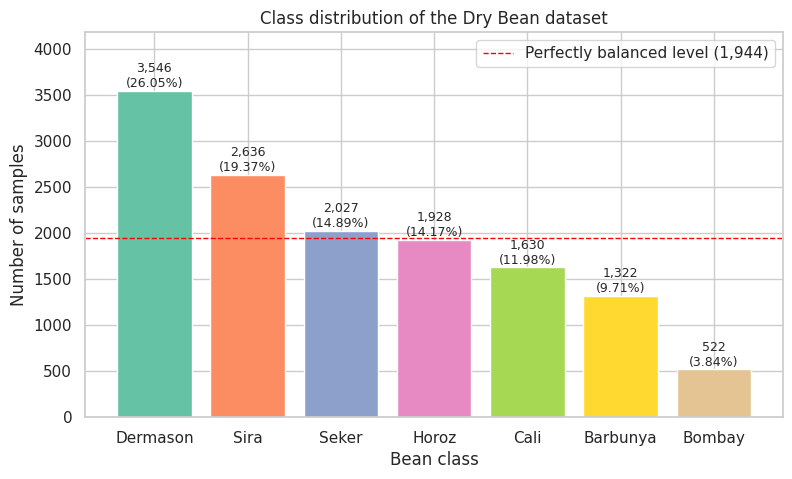

In [10]:
class_counts_sorted = df[TARGET].value_counts()
class_table = pd.DataFrame({
    "Count": class_counts_sorted,
    "Percent": (class_counts_sorted / len(df) * 100).round(2),
})
save_table(class_table, "class_distribution.csv")
display(class_table)

largest, smallest = class_counts_sorted.idxmax(), class_counts_sorted.idxmin()
imbalance_ratio = class_counts_sorted.max() / class_counts_sorted.min()
majority_baseline = class_counts_sorted.max() / len(df)
print(f"Largest class : {largest} ({class_counts_sorted.max():,} samples)")
print(f"Smallest class: {smallest} ({class_counts_sorted.min():,} samples)")
print(f"Imbalance ratio (largest / smallest): {imbalance_ratio:.2f}")
print(f"Accuracy of a 'always predict {largest}' model: {majority_baseline:.2%}")

fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette("Set2", len(class_counts_sorted))
bars = ax.bar(title_case(class_counts_sorted.index), class_counts_sorted.values, color=palette)
for bar, cnt, pct in zip(bars, class_table["Count"], class_table["Percent"]):
    ax.text(bar.get_x() + bar.get_width() / 2, cnt + 40, f"{cnt:,}\n({pct}%)", ha="center", fontsize=9)
ax.axhline(len(df) / 7, color="red", ls="--", lw=1, label=f"Perfectly balanced level ({len(df)/7:,.0f})")
ax.set_title("Class distribution of the Dry Bean dataset")
ax.set_xlabel("Bean class"); ax.set_ylabel("Number of samples")
ax.set_ylim(0, class_counts_sorted.max() * 1.18); ax.legend()
save_fig(fig, "class_distribution.png"); plt.show()

**تحلیل:** کلاس‌ها **متوازن نیستند**. بزرگ‌ترین کلاس (Dermason) حدود ۶٫۸ برابر کوچک‌ترین کلاس (Bombay) است.

**چرا Accuracy کلی می‌تواند گمراه‌کننده باشد؟** Accuracy نسبت پیش‌بینی‌های درست به **کل نمونه‌ها** است؛ پس کلاس‌های بزرگ وزن بیشتری در آن دارند. مدلی که همهٔ نمونه‌ها را Dermason بگوید بدون یادگیری هیچ الگویی حدود ۲۶٪ Accuracy می‌گیرد، و مدلی که کلاس کوچکی مانند Bombay را کاملاً اشتباه تشخیص دهد فقط چند درصد از Accuracy کلی را از دست می‌دهد. یعنی Accuracy بالا می‌تواند ضعف روی کلاس‌های کوچک را پنهان کند؛ به همین دلیل در کنار آن Recall و F1 هر کلاس و میانگین **Macro** (که همهٔ کلاس‌ها را هم‌وزن می‌گیرد) گزارش می‌شود.

## ۴. آمار توصیفی

آمار هفت ویژگی خواسته‌شده: Mean، Median، Std، Min، Max و صدک‌های ۲۵، ۵۰، ۷۵ و ۹۰.

In [11]:
required_features = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength",
                     "Eccentricity", "Roundness", "Compactness"]
stats_table = pd.DataFrame({
    "Mean": df[required_features].mean(),
    "Median": df[required_features].median(),
    "Std": df[required_features].std(),
    "Min": df[required_features].min(),
    "Max": df[required_features].max(),
    "P25": df[required_features].quantile(0.25),
    "P50": df[required_features].quantile(0.50),
    "P75": df[required_features].quantile(0.75),
    "P90": df[required_features].quantile(0.90),
}).T
stats_table.index.name = "Statistic"
save_table(stats_table, "descriptive_statistics.csv")
display(stats_table)

# Mean of each required feature per class (well above the "at least three" requirement)
class_means = df.groupby(TARGET)[required_features].mean()
save_table(class_means, "class_means.csv")
display(class_means)

# Relative spread between classes: (max class mean / min class mean)
between_class_ratio = (class_means.max() / class_means.min()).sort_values(ascending=False)
print("Max/min ratio of class means (larger = more separating power on its own):")
display(between_class_ratio.to_frame("ratio"))

Max/min ratio of class means (larger = more separating power on its own):


,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,Roundness,Compactness
Mean,53048.2845,855.2835,320.1419,202.2707,0.7509,0.8733,0.7999
Median,44652.0000,794.9410,296.8834,192.4317,0.7644,0.8832,0.8013
Std,29324.0957,214.2897,85.6942,44.9701,0.0920,0.0595,0.0617
Min,20420.0000,524.7360,183.6012,122.5127,0.2190,0.4896,0.6406
Max,254616.0000,1985.3700,738.8602,460.1985,0.9114,0.9907,0.9873
P25,36328.0000,703.5235,253.3036,175.8482,0.7159,0.8321,0.7625
P50,44652.0000,794.9410,296.8834,192.4317,0.7644,0.8832,0.8013
P75,61332.0000,977.2130,376.4950,217.0317,0.8105,0.9169,0.8343
P90,78114.0000,1093.8580,416.8629,246.6858,0.8612,0.9452,0.8883


,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,Roundness,Compactness
Class,,,,,,,
BARBUNYA,69804.1331,1046.1058,370.0443,240.3094,0.7547,0.8002,0.8050
BOMBAY,173485.0594,1585.6191,593.1521,374.3525,0.7705,0.8644,0.7926
CALI,75538.2110,1057.6343,409.4995,236.3706,0.8148,0.8459,0.7567
DERMASON,32118.7109,665.2095,246.5573,165.6571,0.7366,0.9081,0.8191
HOROZ,53648.5088,919.8597,372.5703,184.1707,0.8674,0.7944,0.7009
SEKER,39881.3000,727.6724,251.2920,201.9097,0.5848,0.9445,0.8968
SIRA,44729.1286,796.4187,299.3803,190.8002,0.7673,0.8847,0.7973


,ratio
Area,5.4014
MajorAxisLength,2.4057
Perimeter,2.3836
MinorAxisLength,2.2598
Eccentricity,1.4834
Compactness,1.2796
Roundness,1.1889


**تفسیر:** میانگین Area و Perimeter بین کلاس‌ها اختلاف زیادی دارد و Bombay با اختلاف در بالاست؛ Bombay دانه‌ای درشت‌تر از بقیه است. در مقابل، Roundness و Compactness بین کلاس‌ها اختلاف نسبتاً کمی دارند و اطلاعات آن‌ها بیشتر «شکل» است تا «اندازه». همچنین دامنهٔ Area (ده‌ها هزار تا بیش از ۲۵۰ هزار) با Roundness (حدود ۰٫۵ تا ۱) قابل مقایسه نیست؛ این موضوع اهمیت Scale را در بخش ۶ توجیه می‌کند. در Area و Perimeter میانگین بزرگ‌تر از میانه است که نشانهٔ چولگی به راست (وجود دانه‌های درشت) است.

## ۵. تحلیل تصویری

Skewness of Area: 2.95


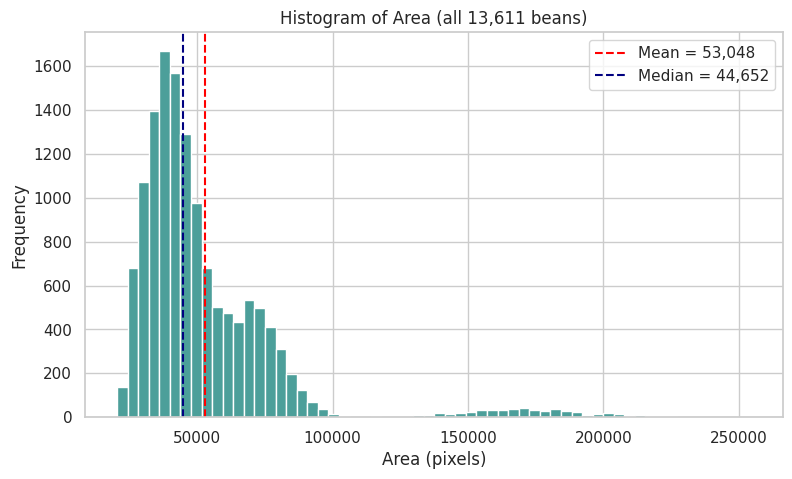

In [12]:
# One reproducible random sample of 2000 beans is used ONLY for scatter plots.
df_plot = df.sample(n=PLOT_SAMPLE_SIZE, random_state=RANDOM_STATE)
class_color = dict(zip(class_labels, sns.color_palette("tab10", len(class_labels))))

# --- 5.1 Histogram of Area (all data) ---------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["Area"], bins=60, color="#4c9f9a", edgecolor="white")
ax.axvline(df["Area"].mean(), color="red", ls="--", label=f"Mean = {df['Area'].mean():,.0f}")
ax.axvline(df["Area"].median(), color="navy", ls="--", label=f"Median = {df['Area'].median():,.0f}")
ax.set_title("Histogram of Area (all 13,611 beans)")
ax.set_xlabel("Area (pixels)"); ax.set_ylabel("Frequency"); ax.legend()
save_fig(fig, "area_histogram.png"); plt.show()
print(f"Skewness of Area: {df['Area'].skew():.2f}")

Median Area per class (ascending):


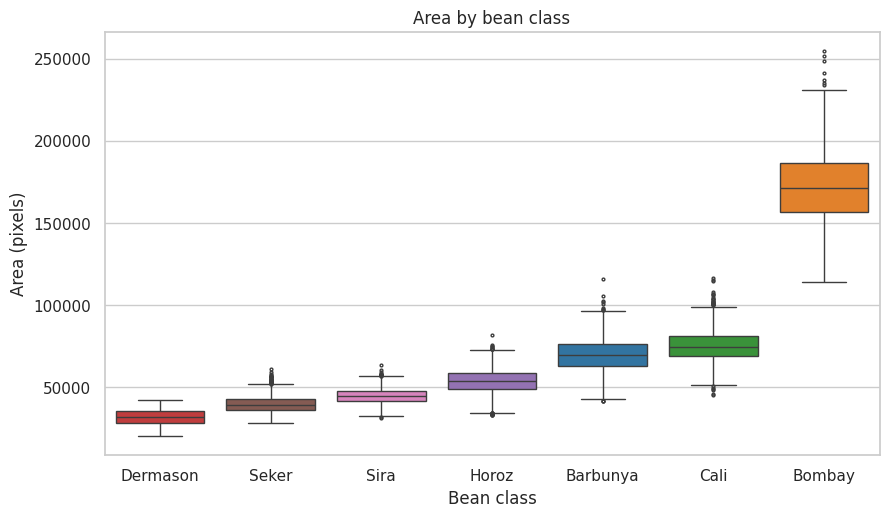

,median_area
Class,
DERMASON,31890.0
SEKER,39180.0
SIRA,44593.0
HOROZ,53800.5
BARBUNYA,69582.0
CALI,74791.5
BOMBAY,171494.5


In [13]:
# --- 5.2 Boxplot of Area by Class (all data) --------------------------------------
order = df.groupby(TARGET)["Area"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=df, x=TARGET, y="Area", order=order, hue=TARGET, hue_order=order,
            palette=class_color, legend=False, fliersize=2, ax=ax)
ax.set_xticks(range(len(order))); ax.set_xticklabels(title_case(order))
ax.set_title("Area by bean class"); ax.set_xlabel("Bean class"); ax.set_ylabel("Area (pixels)")
save_fig(fig, "area_boxplot_by_class.png"); plt.show()
print("Median Area per class (ascending):")
display(df.groupby(TARGET)["Area"].median().sort_values().to_frame("median_area"))

Correlation Area~Perimeter          : 0.9667
Correlation Compactness~Eccentricity: -0.9703


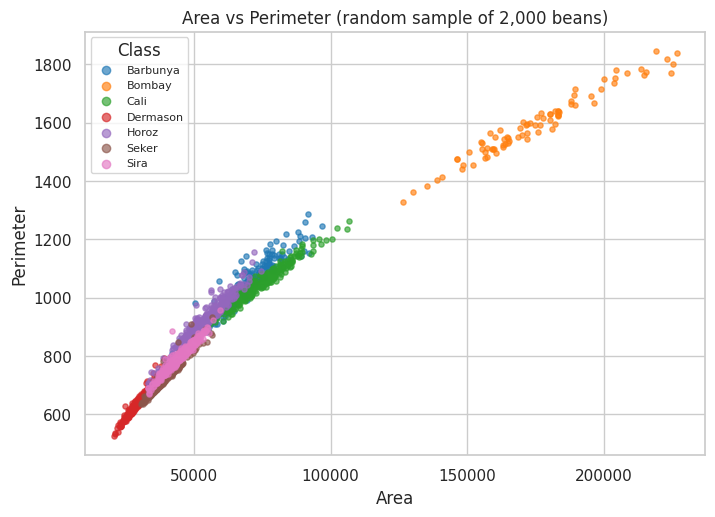

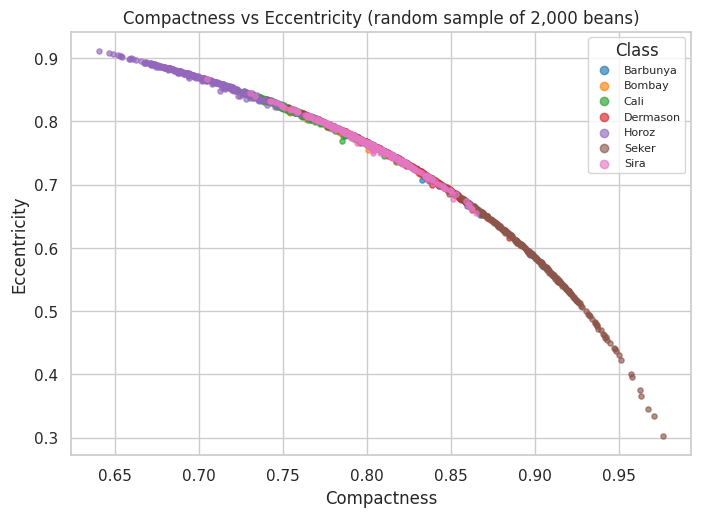

In [14]:
def class_scatter(ax, data, x, y, title):
    """Scatter plot with one colour per real class."""
    for cls in class_labels:
        part = data[data[TARGET] == cls]
        ax.scatter(part[x], part[y], s=14, alpha=0.65, color=class_color[cls], label=cls.title())
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(title)
    ax.legend(title="Class", markerscale=1.6, fontsize=8)

# --- 5.3 Area vs Perimeter ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))
class_scatter(ax, df_plot, "Area", "Perimeter", "Area vs Perimeter (random sample of 2,000 beans)")
save_fig(fig, "area_perimeter_scatter.png"); plt.show()

# --- 5.4 Compactness vs Eccentricity -----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))
class_scatter(ax, df_plot, "Compactness", "Eccentricity",
              "Compactness vs Eccentricity (random sample of 2,000 beans)")
save_fig(fig, "compactness_eccentricity_scatter.png"); plt.show()

print("Correlation Area~Perimeter          :", round(df["Area"].corr(df["Perimeter"]), 4))
print("Correlation Compactness~Eccentricity:", round(df["Compactness"].corr(df["Eccentricity"]), 4))

Feature pairs with |r| >= 0.95: 15


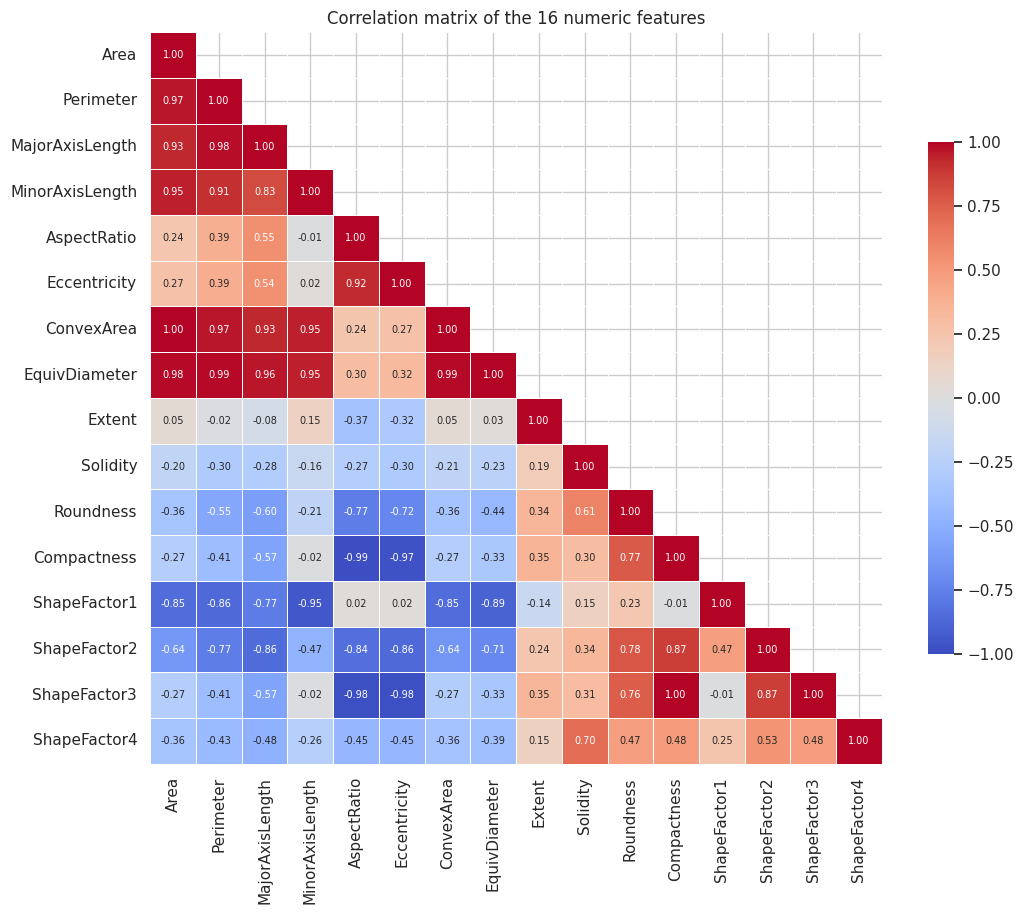

,,correlation
Area,ConvexArea,0.9999
Compactness,ShapeFactor3,0.9987
Perimeter,EquivDiameter,0.9914
AspectRatio,Compactness,-0.9877
ConvexArea,EquivDiameter,0.9852
Area,EquivDiameter,0.9850
Eccentricity,ShapeFactor3,-0.9811
AspectRatio,ShapeFactor3,-0.9786
Perimeter,MajorAxisLength,0.9773
Eccentricity,Compactness,-0.9703


In [15]:
# --- 5.5 Correlation matrix of all 16 features ---------------------------------------
corr = df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt=".2f",
            annot_kws={"size": 7}, cmap="coolwarm", vmin=-1, vmax=1, square=True,
            linewidths=0.4, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation matrix of the 16 numeric features")
save_fig(fig, "correlation_matrix.png"); plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
high_pairs = pairs[pairs.abs() >= 0.95].sort_values(key=abs, ascending=False)
save_table(high_pairs.rename("correlation").to_frame(), "high_correlation_pairs.csv")
print(f"Feature pairs with |r| >= 0.95: {len(high_pairs)}")
display(high_pairs.rename("correlation").to_frame())

**تفسیر نمودارها**
- **هیستوگرام Area:** توزیع چوله به راست است (میانگین > میانه)؛ بیشتر دانه‌ها متوسط/کوچک‌اند و دم بلند سمت راست عمدتاً از دانه‌های درشت (به‌ویژه Bombay) می‌آید.
- **Boxplot:** میانهٔ Area بین کلاس‌ها تفاوت واضح دارد؛ Bombay کاملاً جدا و بالاتر است، در حالی که Dermason، Sira و Seker بازه‌های نزدیک و هم‌پوشان دارند.
- **Area–Perimeter:** رابطهٔ مثبت و بسیار قوی؛ این دو ویژگی تقریباً یک اطلاعات را (اندازه) می‌دهند. Bombay جدا و بقیه هم‌پوشان‌اند.
- **Compactness–Eccentricity:** رابطهٔ منفی و بسیار قوی (r≈−۰٫۹۷)؛ دو ویژگی «شکل» تقریباً یک بعد را می‌سازند. Horoz کشیده‌ترین کلاس است (میانگین Eccentricity حدود ۰٫۸۷ و Compactness حدود ۰٫۷۰) و Seker گردترین (Eccentricity حدود ۰٫۵۸ و Compactness حدود ۰٫۹۰)؛ بقیه بین این دو قرار دارند و به‌شدت هم‌پوشان‌اند.
- **ماتریس همبستگی:** ویژگی‌های اندازه (Area، Perimeter، ConvexArea، EquivDiameter و تا حدی MajorAxisLength) و ویژگی‌های شکل (AspectRatio، Eccentricity، Compactness، ShapeFactor2/3/4) دو خوشهٔ به‌شدت همبسته‌اند؛ پس ۱۶ ویژگی به‌هیچ‌وجه ۱۶ اطلاعات مستقل نیستند (بخش ۱۲).

نمودارهای پراکندگی فقط برای خوانایی از ۲۰۰۰ نمونهٔ تصادفی (`random_state=42`) استفاده می‌کنند؛ تمام مدل‌های بعدی با **کل داده** آموزش می‌بینند.

## ۶. تقسیم Train/Test و Scale

`X` فقط شامل ۱۶ ویژگی عددی و `y` فقط شامل `Class` است. تقسیم دقیقاً مطابق پروژه انجام می‌شود: ۸۰٪ Train، ۲۰٪ Test، `random_state=42` و `stratify=y`.

In [16]:
X = df[feature_cols].copy()
y = df[TARGET].copy()

# Safety checks: the label can never leak into the model inputs
assert TARGET not in X.columns
assert list(X.columns) == feature_cols and X.shape[1] == 16
assert all(pd.api.types.is_numeric_dtype(X[c]) for c in X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

split_table = pd.DataFrame({
    "Train count": y_train.value_counts().sort_index(),
    "Train %": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "Test count": y_test.value_counts().sort_index(),
    "Test %": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
    "Full-data %": (y.value_counts(normalize=True).sort_index() * 100).round(2),
})
split_table.loc["TOTAL"] = [len(y_train), 100.0, len(y_test), 100.0, 100.0]
save_table(split_table, "train_test_class_distribution.csv")
print(f"Train: {X_train.shape}   Test: {X_test.shape}")
display(split_table)

Train: (10888, 16)   Test: (2723, 16)


,Train count,Train %,Test count,Test %,Full-data %
Class,,,,,
BARBUNYA,1057.0,9.71,265.0,9.73,9.71
BOMBAY,418.0,3.84,104.0,3.82,3.84
CALI,1304.0,11.98,326.0,11.97,11.98
DERMASON,2837.0,26.06,709.0,26.04,26.05
HOROZ,1542.0,14.16,386.0,14.18,14.17
SEKER,1621.0,14.89,406.0,14.91,14.89
SIRA,2109.0,19.37,527.0,19.35,19.37
TOTAL,10888.0,100.00,2723.0,100.00,100.00


### اثر تکراری‌ها بر ارزیابی (تحلیل حساسیت)

در بخش ۲ تکراری‌ها را حذف نکردیم. اینجا اندازه می‌گیریم چند نمونهٔ Test دقیقاً یک «همزاد» با ویژگی‌های یکسان در Train دارند. برای این نمونه‌ها KNN هم‌سایهٔ با فاصلهٔ صفر دارد؛ پس ممکن است Accuracy کمی خوش‌بینانه شود. این بررسی فقط **گزارش** است و روش تقسیم را تغییر نمی‌دهد. (در بخش ۷ Accuracy روی نمونه‌های بدون همزاد هم گزارش می‌شود.)

In [17]:
train_keys = set(map(tuple, X_train.to_numpy()))
test_has_twin = np.array([tuple(row) in train_keys for row in X_test.to_numpy()])
print(f"Test rows with an exact feature twin in Train: {test_has_twin.sum()} of {len(X_test)} "
      f"({test_has_twin.mean():.2%})")

Test rows with an exact feature twin in Train: 23 of 2723 (0.84%)


In [18]:
# --- Scaling: fit ONLY on the training data ---------------------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)     # learn mean/std from Train only
X_test_s = scaler.transform(X_test)           # apply the Train statistics to Test
assert scaler.n_samples_seen_ == len(X_train), "Scaler must have seen Train only"

scaling_effect = pd.DataFrame({
    "Mean (raw train)": X_train.mean(),
    "Std (raw train)": X_train.std(ddof=0),
    "Mean (scaled train)": X_train_s.mean(axis=0),
    "Std (scaled train)": X_train_s.std(axis=0),
    "Mean (scaled test)": X_test_s.mean(axis=0),
    "Std (scaled test)": X_test_s.std(axis=0),
}, index=feature_cols)
save_table(scaling_effect, "scaling_effect.csv")
display(scaling_effect.round(4))

# How much does each feature drive raw Euclidean distances? (random train pairs)
rng = np.random.default_rng(RANDOM_STATE)
i, j = rng.integers(0, len(X_train), 5000), rng.integers(0, len(X_train), 5000)
keep = i != j                                   # drop pairs of a bean with itself (0/0)
i, j = i[keep], j[keep]
def distance_share(M):
    sq = (M[i] - M[j]) ** 2
    return pd.Series((sq / sq.sum(axis=1, keepdims=True)).mean(axis=0), index=feature_cols)
share = pd.DataFrame({"Raw features": distance_share(X_train.to_numpy()),
                      "Scaled features": distance_share(X_train_s)})
print("Average share of squared Euclidean distance contributed by each feature (top 4 raw):")
display((share.sort_values("Raw features", ascending=False).head(4) * 100).round(2))

Average share of squared Euclidean distance contributed by each feature (top 4 raw):


,Mean (raw train),Std (raw train),Mean (scaled train),Std (scaled train),Mean (scaled test),Std (scaled test)
Area,53018.0726,29286.9986,0.0,1.0,0.0052,1.0061
Perimeter,855.0236,214.0709,-0.0,1.0,0.0061,1.0049
MajorAxisLength,320.0480,85.6011,0.0,1.0,0.0055,1.0052
MinorAxisLength,202.2216,44.9668,-0.0,1.0,0.0055,1.0002
AspectRatio,1.5832,0.2467,-0.0,1.0,0.0016,0.9989
Eccentricity,0.7509,0.0919,-0.0,1.0,0.0001,1.0061
ConvexArea,53737.7480,29733.1648,-0.0,1.0,0.0051,1.0068
EquivDiameter,252.9958,59.1426,-0.0,1.0,0.0058,1.0027
Extent,0.7494,0.0490,-0.0,1.0,0.0300,1.0039
Solidity,0.9871,0.0047,0.0,1.0,0.0126,0.9652


,Raw features,Scaled features
ConvexArea,50.83,3.47
Area,49.09,3.47
MajorAxisLength,0.03,4.66
Perimeter,0.03,4.68


**چرا KNN و K-Means به Scale حساس‌اند؟** هر دو الگوریتم بر پایهٔ فاصلهٔ اقلیدسی کار می‌کنند. بدون Scale، ویژگی‌هایی با عددهای بزرگ (مثل Area و ConvexArea در حد ده‌ها هزار) تقریباً تمام فاصله را می‌سازند و ویژگی‌های ۰ تا ۱ (مثل Roundness یا Solidity) عملاً دیده نمی‌شوند؛ جدول بالا این را عددی نشان می‌دهد. پس «همسایه» یا «خوشه» تقریباً فقط بر اساس اندازه تعریف می‌شود. StandardScaler هر ویژگی را به میانگین ۰ و انحراف معیار ۱ می‌رساند تا واحدها اثر بی‌جا نداشته باشند.

**چرا فقط روی Train؟** اگر Scaler با کل داده آموزش ببیند، میانگین و انحراف معیار Test هم در تبدیل نقش دارد و اطلاعات Test به مدل نشت می‌کند (Data Leakage). به همین دلیل میانگین/انحراف معیار Train دقیقاً ۰ و ۱ است، ولی برای Test فقط نزدیک به ۰ و ۱ است — این طبیعی و درست است.

## ۷. مدل KNN

سه مدل با K=3، ۵ و ۹ روی داده‌های Scale‌شده ساخته می‌شود. برای هر مدل: Train/Test Accuracy، ماتریس اغتشاش ۷ کلاسه، Precision/Recall/F1 هر کلاس و Macro Recall / Macro F1.

In [19]:
knn_models, knn_test_pred, knn_train_pred = {}, {}, {}
knn_rows, per_class_tables, confusion = [], {}, {}

for k in K_VALUES:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    train_pred, test_pred = model.predict(X_train_s), model.predict(X_test_s)
    knn_models[k], knn_train_pred[k], knn_test_pred[k] = model, train_pred, test_pred

    prec, rec, f1, sup = precision_recall_fscore_support(
        y_test, test_pred, labels=class_labels, zero_division=0)
    per_class_tables[k] = pd.DataFrame(
        {"Precision": prec, "Recall": rec, "F1-score": f1, "Support": sup}, index=class_labels)
    confusion[k] = confusion_matrix(y_test, test_pred, labels=class_labels)
    knn_rows.append({
        "Model": "KNN", "K": k, "Scale": "Yes",
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Macro Recall": recall_score(y_test, test_pred, average="macro"),
        "Macro F1": f1_score(y_test, test_pred, average="macro"),
    })
    save_table(per_class_tables[k], f"knn_k{k}_per_class_metrics.csv")

print("Detailed per-class metrics for K = 5 (test set):")
display(per_class_tables[5].round(4))
print("\nFull sklearn report for K = 5:")
print(classification_report(y_test, knn_test_pred[5], digits=4))

Detailed per-class metrics for K = 5 (test set):

Full sklearn report for K = 5:
              precision    recall  f1-score   support

    BARBUNYA     0.9508    0.8755    0.9116       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.9167    0.9448    0.9305       326
    DERMASON     0.9099    0.9111    0.9105       709
       HOROZ     0.9530    0.9456    0.9493       386
       SEKER     0.9504    0.9433    0.9468       406
        SIRA     0.8435    0.8691    0.8561       527

    accuracy                         0.9166      2723
   macro avg     0.9320    0.9271    0.9293      2723
weighted avg     0.9174    0.9166    0.9168      2723



,Precision,Recall,F1-score,Support
BARBUNYA,0.9508,0.8755,0.9116,265
BOMBAY,1.0000,1.0000,1.0000,104
CALI,0.9167,0.9448,0.9305,326
DERMASON,0.9099,0.9111,0.9105,709
HOROZ,0.9530,0.9456,0.9493,386
SEKER,0.9504,0.9433,0.9468,406
SIRA,0.8435,0.8691,0.8561,527


In [20]:
# Extra reference row: what happens WITHOUT scaling (K=5), to show the effect of Scale.
raw_knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
raw_train_pred, raw_test_pred = raw_knn.predict(X_train), raw_knn.predict(X_test)
knn_rows.append({
    "Model": "KNN", "K": 5, "Scale": "No (reference)",
    "Train Accuracy": accuracy_score(y_train, raw_train_pred),
    "Test Accuracy": accuracy_score(y_test, raw_test_pred),
    "Macro Recall": recall_score(y_test, raw_test_pred, average="macro"),
    "Macro F1": f1_score(y_test, raw_test_pred, average="macro"),
})
knn_comparison = pd.DataFrame(knn_rows)
save_table(knn_comparison, "knn_comparison_table.csv", index=False)
display(knn_comparison.round(4))

# Sensitivity: accuracy only on Test rows that have NO identical twin in Train
mask = ~test_has_twin
for k in K_VALUES:
    print(f"K={k}: Test accuracy all rows = {accuracy_score(y_test, knn_test_pred[k]):.4f} | "
          f"without twin rows = {accuracy_score(y_test[mask], knn_test_pred[k][mask]):.4f}")

K=3: Test accuracy all rows = 0.9152 | without twin rows = 0.9148
K=5: Test accuracy all rows = 0.9166 | without twin rows = 0.9167
K=9: Test accuracy all rows = 0.9163 | without twin rows = 0.9163


,Model,K,Scale,Train Accuracy,Test Accuracy,Macro Recall,Macro F1
0,KNN,3,Yes,0.9499,0.9152,0.9274,0.9285
1,KNN,5,Yes,0.9415,0.9166,0.9271,0.9293
2,KNN,9,Yes,0.9368,0.9163,0.9267,0.9289
3,KNN,5,No (reference),0.8127,0.7242,0.7229,0.7270


**مقایسهٔ K=3، ۵ و ۹ روی Test:** تفاوت مدل‌ها بسیار کوچک است (چند دهم درصد، معادل چند نمونه از ۲٬۷۲۲ نمونه). با یک تقسیم Train/Test نمی‌توان نتیجه گرفت که کدام K «بهتر» است؛ این اختلاف‌ها در حد نوسان نمونه‌گیری‌اند. همچنین Train Accuracy با بزرگ‌تر شدن K کاهش می‌یابد چون با K کوچک‌تر مدل بیشتر به نمونه‌های آموزشی «نزدیک» می‌شود (در K=1 هر نمونه همسایهٔ خودش است). ردیف «بدون Scale» نشان می‌دهد که حذف Scale عملکرد را کاهش می‌دهد.

برای انتخاب حرفه‌ای K باید از Validation/Cross-Validation **روی Train** استفاده کرد، نه از مشاهدهٔ مکرر Test:

K with highest mean CV macro-F1: 9
Spread of CV macro-F1 across K=3,5,9: 0.0051  (compare with fold std above)


,CV accuracy (mean),CV accuracy (std),CV macro-F1 (mean),CV macro-F1 (std)
K,,,,
1,0.9048,0.0012,0.9205,0.0011
3,0.9193,0.0032,0.9321,0.0042
5,0.9232,0.0047,0.9355,0.0050
7,0.9240,0.0034,0.9363,0.0033
9,0.9256,0.0042,0.9373,0.0043
11,0.9256,0.0055,0.9372,0.0059
15,0.9242,0.0048,0.9358,0.0054
21,0.9253,0.0047,0.9365,0.0050
31,0.9238,0.0051,0.9351,0.0048


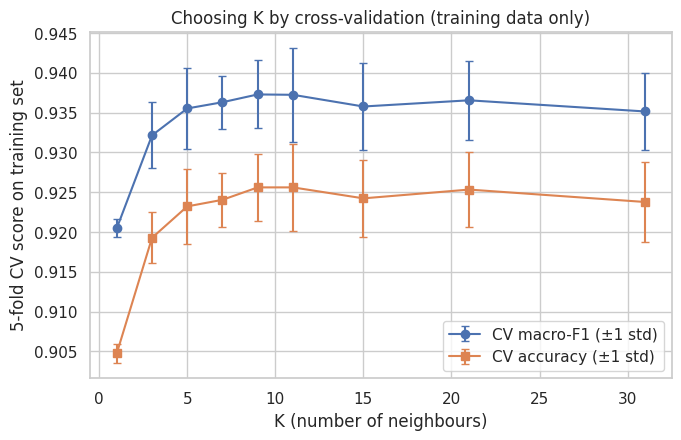

In [21]:
# Cross-validation on the TRAINING set only; the scaler is refit inside every fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
candidate_ks = [1, 3, 5, 7, 9, 11, 15, 21, 31]
cv_rows = []
for k in candidate_ks:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    res = cross_validate(pipe, X_train, y_train, cv=cv, n_jobs=-1,
                         scoring={"acc": "accuracy", "f1": "f1_macro"})
    cv_rows.append({"K": k,
                    "CV accuracy (mean)": res["test_acc"].mean(), "CV accuracy (std)": res["test_acc"].std(),
                    "CV macro-F1 (mean)": res["test_f1"].mean(), "CV macro-F1 (std)": res["test_f1"].std()})
cv_table = pd.DataFrame(cv_rows).set_index("K")
save_table(cv_table, "knn_cross_validation.csv")
display(cv_table.round(4))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(cv_table.index, cv_table["CV macro-F1 (mean)"], yerr=cv_table["CV macro-F1 (std)"],
            marker="o", capsize=3, label="CV macro-F1 (±1 std)")
ax.errorbar(cv_table.index, cv_table["CV accuracy (mean)"], yerr=cv_table["CV accuracy (std)"],
            marker="s", capsize=3, label="CV accuracy (±1 std)")
ax.set_xlabel("K (number of neighbours)"); ax.set_ylabel("5-fold CV score on training set")
ax.set_title("Choosing K by cross-validation (training data only)"); ax.legend()
save_fig(fig, "knn_cv_k_selection.png"); plt.show()

best_cv_k = int(cv_table["CV macro-F1 (mean)"].idxmax())
gap = cv_table["CV macro-F1 (mean)"].max() - cv_table.loc[list(K_VALUES), "CV macro-F1 (mean)"].min()
print(f"K with highest mean CV macro-F1: {best_cv_k}")
print(f"Spread of CV macro-F1 across K=3,5,9: {gap:.4f}  (compare with fold std above)")

**نتیجهٔ Cross-Validation:** K=1 به‌وضوح ضعیف‌تر است (حساس به نویز). از K≈۵ تا ۲۱ منحنی تقریباً تخت است؛ بیشترین میانگین Macro-F1 در K=9 دیده می‌شود (K=11 تقریباً برابر است) اما تفاوت K=5 تا K=21 هم‌مرتبهٔ انحراف معیار بین Foldهاست (حدود ۰٫۰۰۴ تا ۰٫۰۰۶) و K=3 اندکی پایین‌تر است. بنابراین شواهد فقط نشان می‌دهد «K خیلی کوچک بد است و بازهٔ متوسط تقریباً هم‌ارز است»؛ **نمی‌توان مدعی شد یک K بهترین مقدار عمومی است.** انتخاب نهایی باید با اولویت‌های کاربردی (سادگی، سرعت پیش‌بینی، پایداری) انجام شود. K=5 برای گزارش تفصیلی مطابق پروژه انتخاب شده است، نه به‌خاطر برتری اثبات‌شده.

## ۸. تحلیل ماتریس اغتشاش چندکلاسه

ماتریس اغتشاش هفت‌کلاسه با نام کامل انواع لوبیا رسم می‌شود (سطر = کلاس واقعی، ستون = کلاس پیش‌بینی‌شده).

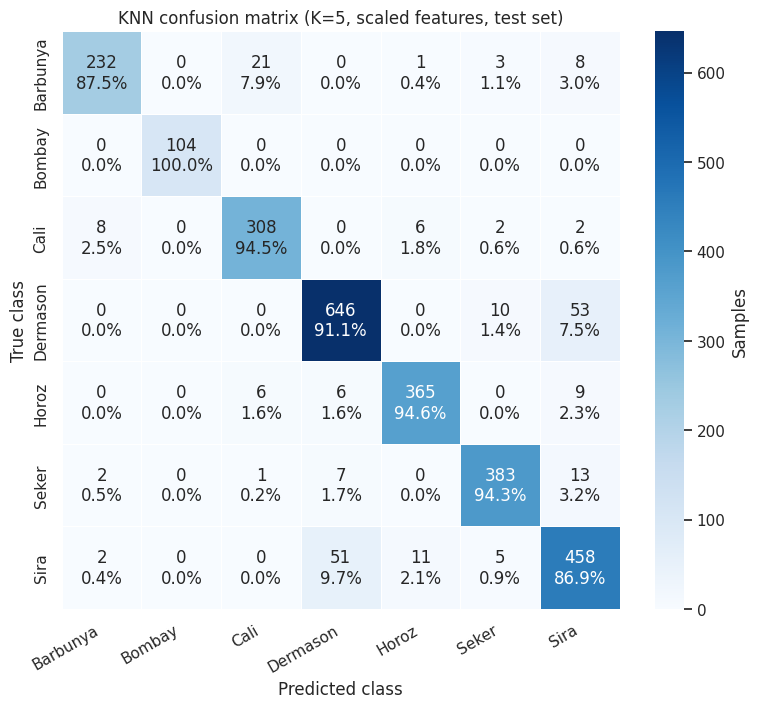

In [22]:
names = title_case(class_labels)

def plot_confusion(cm, k, path_name):
    cm_df = pd.DataFrame(cm, index=names, columns=names)
    row_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f"{cm[r, c]}\n{row_pct[r, c]:.1f}%" for c in range(7)] for r in range(7)])
    fig, ax = plt.subplots(figsize=(9, 7.5))
    sns.heatmap(cm_df, annot=annot, fmt="", cmap="Blues", linewidths=0.5, cbar_kws={"label": "Samples"}, ax=ax)
    ax.set_title(f"KNN confusion matrix (K={k}, scaled features, test set)")
    ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    save_fig(fig, path_name); plt.show()
    return cm_df

cm_main = plot_confusion(confusion[5], 5, "confusion_matrix_knn_k5.png")
save_table(cm_main, "confusion_matrix_knn_k5.csv")
for k in (3, 9):   # saved for completeness, shown without repeating the plot code
    fig, ax = plt.subplots(figsize=(9, 7.5))
    sns.heatmap(pd.DataFrame(confusion[k], index=names, columns=names), annot=True, fmt="d",
                cmap="Blues", linewidths=0.5, ax=ax)
    ax.set_title(f"KNN confusion matrix (K={k}, scaled features, test set)")
    ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    save_fig(fig, f"confusion_matrix_knn_k{k}.png"); plt.close(fig)
    save_table(pd.DataFrame(confusion[k], index=names, columns=names), f"confusion_matrix_knn_k{k}.csv")

In [23]:
def confusion_analysis(k):
    """Extract the facts requested by the project from the confusion matrix of a K."""
    cm = confusion[k]
    correct = pd.Series(np.diag(cm), index=class_labels)
    recall = per_class_tables[k]["Recall"]
    # Round-trip errors between two classes = errors A->B plus errors B->A.
    pair_errors = {(class_labels[a], class_labels[b]): (int(cm[a, b]), int(cm[b, a]))
                   for a in range(7) for b in range(a + 1, 7)}
    top_pair = max(pair_errors, key=lambda p: sum(pair_errors[p]))
    return correct, recall, top_pair, pair_errors[top_pair], pair_errors

for k in K_VALUES:
    correct, recall, top_pair, (ab, ba), pair_errors = confusion_analysis(k)
    print(f"K={k}: most correct predictions = {correct.idxmax()} ({correct.max()}) | "
          f"lowest recall = {recall.idxmin()} ({recall.min():.3f}) | "
          f"most confused pair = {top_pair[0]}<->{top_pair[1]} ({top_pair[0]}->{top_pair[1]}: {ab}, "
          f"{top_pair[1]}->{top_pair[0]}: {ba}, total {ab + ba})")

correct5, recall5, top_pair5, (err_ab, err_ba), pair_errors5 = confusion_analysis(5)
pair_table = (pd.Series({f"{a} <-> {b}": sum(v) for (a, b), v in pair_errors5.items()})
              .sort_values(ascending=False).head(5).to_frame("round-trip errors (K=5)"))
save_table(pair_table, "top_confused_pairs_k5.csv")
display(pair_table)

K=3: most correct predictions = DERMASON (647) | lowest recall = SIRA (0.850) | most confused pair = DERMASON<->SIRA (DERMASON->SIRA: 53, SIRA->DERMASON: 57, total 110)
K=5: most correct predictions = DERMASON (646) | lowest recall = SIRA (0.869) | most confused pair = DERMASON<->SIRA (DERMASON->SIRA: 53, SIRA->DERMASON: 51, total 104)
K=9: most correct predictions = DERMASON (644) | lowest recall = BARBUNYA (0.868) | most confused pair = DERMASON<->SIRA (DERMASON->SIRA: 54, SIRA->DERMASON: 52, total 106)


,round-trip errors (K=5)
DERMASON <-> SIRA,104
BARBUNYA <-> CALI,29
HOROZ <-> SIRA,20
SEKER <-> SIRA,18
DERMASON <-> SEKER,17


In [24]:
# Why are the two most confused classes confused? Compare their feature distributions.
cls_a, cls_b = top_pair5
pair_df = df[df[TARGET].isin([cls_a, cls_b])]
pooled_std = np.sqrt((df[df[TARGET] == cls_a][feature_cols].var() +
                      df[df[TARGET] == cls_b][feature_cols].var()) / 2)
similarity = pd.DataFrame({
    f"Mean {cls_a}": df[df[TARGET] == cls_a][feature_cols].mean(),
    f"Mean {cls_b}": df[df[TARGET] == cls_b][feature_cols].mean(),
    "Abs. mean diff (in pooled std, Cohen d)": (
        (df[df[TARGET] == cls_a][feature_cols].mean() - df[df[TARGET] == cls_b][feature_cols].mean()).abs()
        / pooled_std),
}).sort_values("Abs. mean diff (in pooled std, Cohen d)")
save_table(similarity, "most_confused_pair_feature_similarity.csv")
print(f"Most confused pair: {cls_a} vs {cls_b}. Features sorted from MOST similar to MOST different:")
display(similarity)

Most confused pair: DERMASON vs SIRA. Features sorted from MOST similar to MOST different:


,Mean DERMASON,Mean SIRA,"Abs. mean diff (in pooled std, Cohen d)"
Extent,0.7530,0.7494,0.0853
Solidity,0.9882,0.9880,0.0887
ShapeFactor4,0.9969,0.9954,0.6639
AspectRatio,1.4905,1.5701,0.8251
Eccentricity,0.7366,0.7673,0.8348
Compactness,0.8191,0.7973,0.8553
ShapeFactor3,0.6716,0.6364,0.8571
Roundness,0.9081,0.8847,0.8777
ShapeFactor2,0.0022,0.0017,1.9339
ShapeFactor1,0.0078,0.0067,2.1500


**تفسیر ماتریس اغتشاش (K=5):**
- **بیشترین پیش‌بینی صحیح** به Dermason تعلق دارد (۶۴۶ نمونه)، اما این عمدتاً به‌خاطر بزرگ‌ترین کلاس بودن آن است، نه بهترین عملکرد؛ Recall آن حدود ۰٫۹۱ است.
- **کمترین Recall در K=5** مربوط به **Sira** (حدود ۰٫۸۶۹) است و Barbunya (حدود ۰٫۸۷۵) با اختلاف بسیار کم بعد از آن قرار می‌گیرد؛ در K=9 جایگاه این دو جابه‌جا می‌شود. یعنی این دو کلاس در حد نوسان با هم برابرند و ادعای «فقط یک کلاس ضعیف‌ترین است» با یک تقسیم Test قابل اثبات نیست. Sira همچنین کمترین Precision (حدود ۰٫۸۴) را دارد چون نمونه‌هایی از Dermason، Horoz و Seker به آن نسبت داده می‌شوند.
- **بیشترین اشتباه** بین **Dermason و Sira** است (۵۳ خطا از Dermason به Sira و ۵۱ خطا از Sira به Dermason؛ جمعاً ۱۰۴ خطای رفت‌وبرگشت). جدول شباهت نشان می‌دهد ویژگی‌های شکل این دو کلاس تقریباً یکی است: Extent و Solidity عملاً برابرند (اختلاف میانگین کمتر از ۰٫۱ انحراف معیار)، و Roundness، Compactness، Eccentricity، AspectRatio و ShapeFactor3 اختلاف کمتر از حدود ۰٫۹ انحراف معیار دارند. تفاوت اصلی در اندازه است (Area میانگین حدود ۳۲ هزار در برابر ۴۵ هزار) ولی چون Sira دامنهٔ اندازهٔ گسترده‌ای دارد، دانه‌های کوچک Sira و دانه‌های بزرگ Dermason در ناحیهٔ مرزی روی هم می‌افتند و همسایه‌هایشان از کلاس دیگر می‌آید.
- **دومین جفت پرخطا** Barbunya و Cali (۲۹ خطای رفت‌وبرگشت) است؛ هر دو کلاس دانه‌های درشتی‌اند (میانگین Area حدود ۷۰ و ۷۵ هزار) و بیشتر خطاهای Barbunya (۲۱ از ۳۳ خطا) به Cali می‌رود.
- **Bombay** با Recall و Precision برابر ۱ کاملاً جداست، چون میانگین Area آن حدود ۲ تا ۵ برابر بقیهٔ کلاس‌هاست.

## ۹. خوشه‌بندی K-Means

`KMeans(n_clusters=7, random_state=42, n_init=10)` فقط با ویژگی‌های Scale‌شدهٔ **Train** آموزش می‌بیند و **هیچ برچسب کلاسی** به آن داده نمی‌شود. سپس برای نمونه‌های Test شمارهٔ Cluster پیش‌بینی می‌شود. شمارهٔ Cluster فقط شناسه است و ترتیب یا نام کلاس‌ها را نشان نمی‌دهد (در ادامه با یک اجرای دیگر نشان می‌دهیم شماره‌ها جابه‌جا می‌شوند).

In [25]:
kmeans = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_train_s)                         # only scaled TRAIN features, NO labels
train_clusters = kmeans.labels_
test_clusters = kmeans.predict(X_test_s)

sizes = pd.DataFrame({
    "Train samples": pd.Series(train_clusters).value_counts().sort_index(),
    "Test samples": pd.Series(test_clusters).value_counts().sort_index(),
}).fillna(0).astype(int)
sizes.index.name = "Cluster"
save_table(sizes, "kmeans_cluster_sizes.csv")
display(sizes)

# Crosstab: true class (rows) vs generated cluster (columns)
crosstab_test = pd.crosstab(y_test, pd.Series(test_clusters, index=y_test.index, name="Cluster"))
crosstab_train = pd.crosstab(y_train, pd.Series(train_clusters, index=y_train.index, name="Cluster"))
save_table(crosstab_test, "class_cluster_crosstab_test.csv")
save_table(crosstab_train, "class_cluster_crosstab_train.csv")
print("Crosstab on the TEST set (true class x predicted cluster):")
display(crosstab_test)
print("Crosstab on the TRAIN set (the data K-Means was fitted on):")
display(crosstab_train)

Crosstab on the TEST set (true class x predicted cluster):
Crosstab on the TRAIN set (the data K-Means was fitted on):


,Train samples,Test samples
Cluster,,
0,1618,411
1,2001,505
2,2557,624
3,417,103
4,2468,631
5,1423,349
6,404,100


Cluster,0,1,2,3,4,5,6
Class,,,,,,,
BARBUNYA,4,233,0,0,21,1,6
BOMBAY,0,0,0,103,0,0,1
CALI,2,266,0,0,3,6,49
DERMASON,21,0,581,0,105,0,2
HOROZ,0,6,0,0,13,332,35
SEKER,378,0,9,0,19,0,0
SIRA,6,0,34,0,470,10,7


Cluster,0,1,2,3,4,5,6
Class,,,,,,,
BARBUNYA,14,909,0,0,96,7,31
BOMBAY,0,1,0,417,0,0,0
CALI,0,1062,0,0,25,21,196
DERMASON,93,0,2347,0,380,7,10
HOROZ,0,24,2,0,36,1334,146
SEKER,1494,0,45,0,79,0,3
SIRA,17,5,163,0,1852,54,18


Adjusted Rand Index (test) : 0.674   (1 = identical partitions, 0 = random)
Normalized Mutual Info     : 0.722
Silhouette (train, sample) : 0.313
NOTE: no accuracy is computed between cluster IDs and class labels (no mapping is defined).


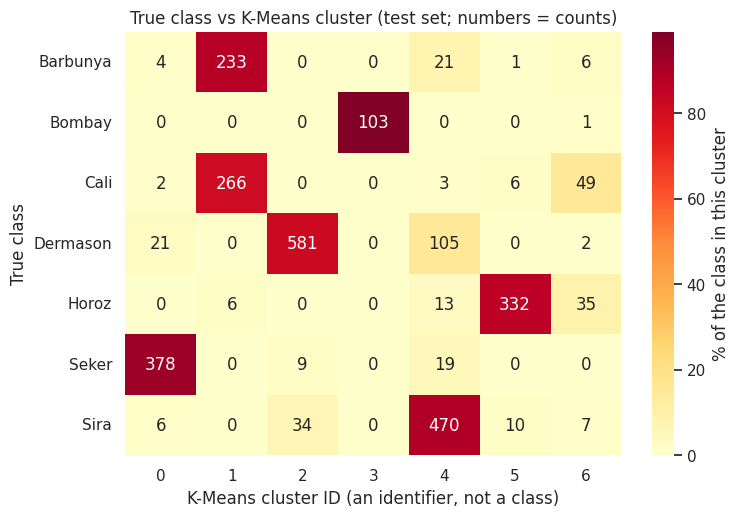

In [26]:
# Heatmap of the test crosstab, normalised by class (row) so small classes remain visible.
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(crosstab_test.div(crosstab_test.sum(axis=1), axis=0) * 100, annot=crosstab_test.to_numpy(),
            fmt="d", cmap="YlOrRd", yticklabels=names, cbar_kws={"label": "% of the class in this cluster"}, ax=ax)
ax.set_title("True class vs K-Means cluster (test set; numbers = counts)")
ax.set_xlabel("K-Means cluster ID (an identifier, not a class)"); ax.set_ylabel("True class")
save_fig(fig, "class_cluster_crosstab_heatmap.png"); plt.show()

# Cluster-quality indices that need NO cluster->class mapping (documented external indices)
ari = adjusted_rand_score(y_test, test_clusters)
nmi = normalized_mutual_info_score(y_test, test_clusters)
sil = silhouette_score(X_train_s, train_clusters, sample_size=3000, random_state=RANDOM_STATE)
print(f"Adjusted Rand Index (test) : {ari:.3f}   (1 = identical partitions, 0 = random)")
print(f"Normalized Mutual Info     : {nmi:.3f}")
print(f"Silhouette (train, sample) : {sil:.3f}")
print("NOTE: no accuracy is computed between cluster IDs and class labels (no mapping is defined).")

In [27]:
# Supplementary evidence: is K-Means also sensitive to scaling?  (same settings, RAW features)
km_raw = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=10).fit(X_train)
ari_raw = adjusted_rand_score(y_test, km_raw.predict(X_test))
print(f"ARI with scaled features: {ari:.3f}  |  ARI with raw (unscaled) features: {ari_raw:.3f}")

# Is 7 clusters a natural choice for the data itself? (inertia / silhouette for several k)
rows = []
for k in range(3, 11):
    m = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_train_s)
    rows.append({"k": k, "Inertia": m.inertia_,
                 "Silhouette": silhouette_score(X_train_s, m.labels_, sample_size=3000, random_state=RANDOM_STATE)})
k_scan = pd.DataFrame(rows).set_index("k")
save_table(k_scan, "kmeans_k_scan.csv")
display(k_scan.round(4))

# Cluster IDs are arbitrary: a different random_state gives the SAME kind of groups, other numbers.
km_alt = KMeans(n_clusters=7, random_state=7, n_init=10).fit(X_train_s)
alt_clusters = km_alt.predict(X_test_s)
print(f"\nARI between the two K-Means solutions (random_state 42 vs 7): {adjusted_rand_score(test_clusters, alt_clusters):.3f}")
print("Main cluster id of each class, random_state=42 vs random_state=7:")
display(pd.DataFrame({
    "cluster id (rs=42)": pd.crosstab(y_test, test_clusters).idxmax(axis=1),
    "cluster id (rs=7)": pd.crosstab(y_test, alt_clusters).idxmax(axis=1)}))

ARI with scaled features: 0.674  |  ARI with raw (unscaled) features: 0.378

ARI between the two K-Means solutions (random_state 42 vs 7): 0.999
Main cluster id of each class, random_state=42 vs random_state=7:


,Inertia,Silhouette
k,,
3,75690.0692,0.4060
4,61095.0365,0.3406
5,49440.0580,0.3579
6,43875.0932,0.3603
7,38849.7939,0.3127
8,36004.8726,0.3059
9,33397.3708,0.3078
10,31652.4581,0.2920


,cluster id (rs=42),cluster id (rs=7)
Class,,
BARBUNYA,1,0
BOMBAY,3,5
CALI,1,0
DERMASON,2,1
HOROZ,5,3
SEKER,0,2
SIRA,4,6


### جدول خلاصهٔ هر Cluster

In [28]:
def cluster_summary(clusters, labels, min_share=0.05):
    """Per-cluster size, dominant class, its share, and the other classes above min_share."""
    rows = []
    for c in sorted(np.unique(clusters)):
        members = labels[clusters == c]
        share = members.value_counts(normalize=True)
        dominant = share.index[0]
        others = [f"{cls.title()} ({p:.1%})" for cls, p in share.iloc[1:].items() if p >= min_share]
        rows.append({"Cluster": c, "Members": len(members), "Dominant class": dominant.title(),
                     "Dominant class %": round(share.iloc[0] * 100, 1),
                     "Other important classes (>=5%)": ", ".join(others) if others else "-"})
    return pd.DataFrame(rows).set_index("Cluster")

kmeans_table = cluster_summary(train_clusters, y_train.reset_index(drop=True))
kmeans_table_test = cluster_summary(test_clusters, y_test.reset_index(drop=True))
save_table(kmeans_table, "kmeans_cluster_table_train.csv")
save_table(kmeans_table_test, "kmeans_cluster_table_test.csv")
print("K-Means table on TRAIN data (the data used to fit the clusters):")
display(kmeans_table)
print("Same table on TEST data (clusters predicted for unseen beans):")
display(kmeans_table_test)

# Where does each real class go?  (share of a class in its main cluster)
class_to_cluster = crosstab_train.div(crosstab_train.sum(axis=1), axis=0)
class_spread = pd.DataFrame({
    "Main cluster": class_to_cluster.idxmax(axis=1),
    "Share in main cluster %": (class_to_cluster.max(axis=1) * 100).round(1),
    "Clusters holding >=5% of class": (class_to_cluster >= 0.05).sum(axis=1),
})
save_table(class_spread, "class_spread_over_clusters_train.csv")
display(class_spread)

K-Means table on TRAIN data (the data used to fit the clusters):
Same table on TEST data (clusters predicted for unseen beans):


,Members,Dominant class,Dominant class %,Other important classes (>=5%)
Cluster,,,,
0,1618,Seker,92.3,Dermason (5.7%)
1,2001,Cali,53.1,Barbunya (45.4%)
2,2557,Dermason,91.8,Sira (6.4%)
3,417,Bombay,100.0,-
4,2468,Sira,75.0,Dermason (15.4%)
5,1423,Horoz,93.7,-
6,404,Cali,48.5,"Horoz (36.1%), Barbunya (7.7%)"


,Members,Dominant class,Dominant class %,Other important classes (>=5%)
Cluster,,,,
0,411,Seker,92.0,Dermason (5.1%)
1,505,Cali,52.7,Barbunya (46.1%)
2,624,Dermason,93.1,Sira (5.4%)
3,103,Bombay,100.0,-
4,631,Sira,74.5,Dermason (16.6%)
5,349,Horoz,95.1,-
6,100,Cali,49.0,"Horoz (35.0%), Sira (7.0%), Barbunya (6.0%)"


,Main cluster,Share in main cluster %,Clusters holding >=5% of class
Class,,,
BARBUNYA,1,86.0,2
BOMBAY,3,99.8,1
CALI,1,81.4,2
DERMASON,2,82.7,2
HOROZ,5,86.5,2
SEKER,0,92.2,1
SIRA,4,87.8,2


### خلوص (Purity) خوشه‌ها

**Purity** درصدی از نمونه‌هاست که عضو «کلاس غالب» خوشهٔ خود هستند: برای هر Cluster بزرگ‌ترین کلاس شمرده می‌شود و مجموع این مقدارها بر تعداد کل تقسیم می‌شود. این همان نگاشت مستند «اکثریت» است (هر Cluster ← کلاس غالبش)، نه یک Accuracy بین شناسه و برچسب.
نکته‌ها: (۱) نگاشت اکثریت چندبه‌یک است؛ کلاسی که در هیچ Cluster غالب نباشد (اینجا Barbunya) هرگز «پیش‌بینی» نمی‌شود. (۲) Purity با زیاد شدن تعداد خوشه‌ها بالا می‌رود، پس فقط در کنار ARI/NMI معنا دارد. (۳) برای صداقت، نگاشت را از **Train** می‌گیریم و روی **Test** می‌آزماییم؛ خود Purity‌ی Test چون نگاشت را از همان داده می‌گیرد کمی خوش‌بینانه است.

In [29]:
def purity_score(ct):
    """Sum of the largest class count in every cluster (column) / all samples."""
    return ct.max(axis=0).sum() / ct.to_numpy().sum()

purity_train, purity_test = purity_score(crosstab_train), purity_score(crosstab_test)

# Documented majority mapping learned on TRAIN only, then applied to the unseen TEST beans.
cluster_to_class = crosstab_train.idxmax(axis=0)                      # cluster -> dominant class (train)
mapped_test_pred = pd.Series(test_clusters).map(cluster_to_class).to_numpy()
mapped_test_acc = accuracy_score(y_test, mapped_test_pred)
never_dominant = sorted(set(class_labels) - set(cluster_to_class.values))

purity_table = pd.DataFrame({
    "Dominant class (train)": cluster_to_class.str.title(),
    "Train size": crosstab_train.sum(axis=0),
    "Train purity %": (crosstab_train.max(axis=0) / crosstab_train.sum(axis=0) * 100).round(1),
    "Test size": crosstab_test.sum(axis=0),
    "Test purity %": (crosstab_test.max(axis=0) / crosstab_test.sum(axis=0) * 100).round(1),
})
purity_table.index.name = "Cluster"
save_table(purity_table, "kmeans_purity.csv")
display(purity_table)

print(f"Overall purity, TRAIN (fit data)          : {purity_train:.2%}")
print(f"Overall purity, TEST                       : {purity_test:.2%}")
print(f"Test accuracy of the train-derived majority mapping: {mapped_test_acc:.2%}  (documented mapping, NOT a raw cluster-ID accuracy)")
print(f"Classes that are dominant in NO cluster    : {never_dominant}")
print(f"Reference: always predicting the largest class gives {majority_baseline:.2%}")

Overall purity, TRAIN (fit data)          : 79.92%
Overall purity, TEST                       : 80.02%
Test accuracy of the train-derived majority mapping: 80.02%  (documented mapping, NOT a raw cluster-ID accuracy)
Classes that are dominant in NO cluster    : ['BARBUNYA']
Reference: always predicting the largest class gives 26.05%


,Dominant class (train),Train size,Train purity %,Test size,Test purity %
Cluster,,,,,
0,Seker,1618,92.3,411,92.0
1,Cali,2001,53.1,505,52.7
2,Dermason,2557,91.8,624,93.1
3,Bombay,417,100.0,103,100.0
4,Sira,2468,75.0,631,74.5
5,Horoz,1423,93.7,349,95.1
6,Cali,404,48.5,100,49.0


## ۱۰. مقایسهٔ بصری Class واقعی و Cluster

دو نمودار پراکندگی با **محورهای کاملاً یکسان** (روی نمونه‌های Test): در نمودار اول رنگ = کلاس واقعی، در نمودار دوم رنگ = Clusterی که K-Means پیش‌بینی کرده است. دو جفت ویژگی پیشنهادی پروژه رسم می‌شود.

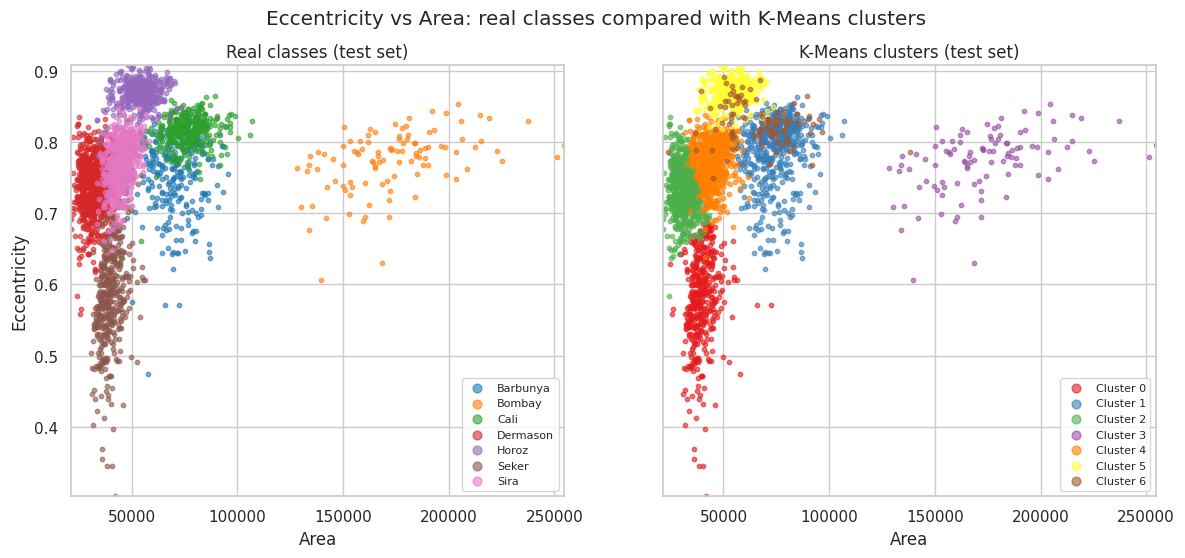

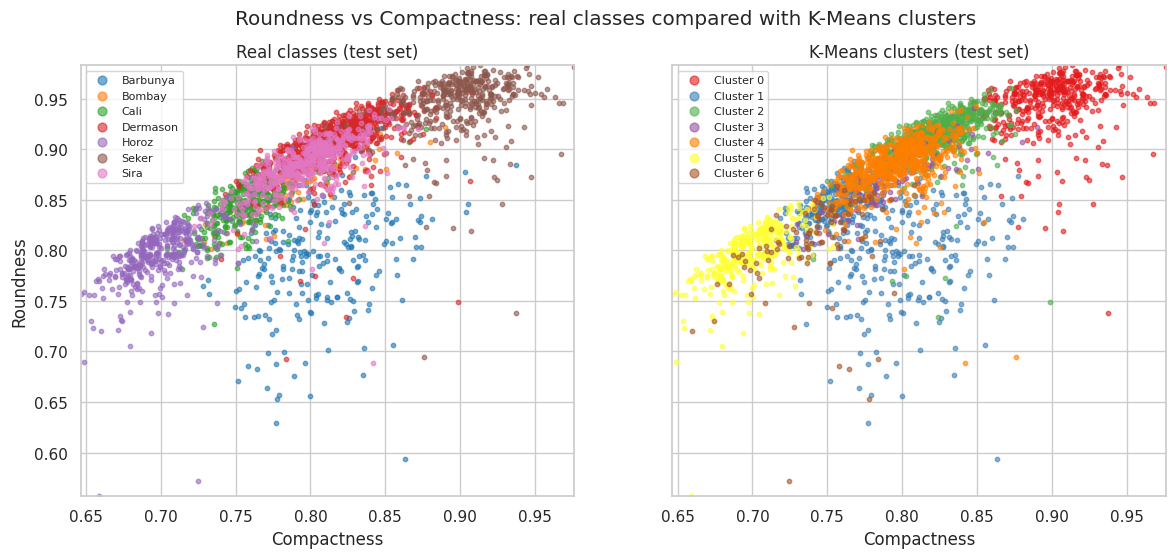

In [30]:
def compare_plot(x_name, y_name, file_name):
    """Two scatter plots with identical axes: true classes vs K-Means clusters (test set)."""
    data = X_test.assign(Class=y_test.values, Cluster=test_clusters)
    xlim = (data[x_name].min(), data[x_name].max())
    ylim = (data[y_name].min(), data[y_name].max())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharex=True, sharey=True)
    for cls in class_labels:
        part = data[data["Class"] == cls]
        axes[0].scatter(part[x_name], part[y_name], s=10, alpha=0.6, color=class_color[cls], label=cls.title())
    cluster_colors = sns.color_palette("Set1", 7)
    for c in range(7):
        part = data[data["Cluster"] == c]
        axes[1].scatter(part[x_name], part[y_name], s=10, alpha=0.6, color=cluster_colors[c], label=f"Cluster {c}")
    axes[0].set_title("Real classes (test set)"); axes[1].set_title("K-Means clusters (test set)")
    for ax in axes:
        ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_xlabel(x_name)
        ax.legend(markerscale=2, fontsize=8)
    axes[0].set_ylabel(y_name)
    fig.suptitle(f"{y_name} vs {x_name}: real classes compared with K-Means clusters")
    save_fig(fig, file_name); plt.show()

compare_plot("Area", "Eccentricity", "class_cluster_comparison.png")
compare_plot("Compactness", "Roundness", "class_cluster_comparison_roundness_compactness.png")

**تفسیر مقایسهٔ Class و Cluster** (بر پایهٔ Crosstab و جدول‌های بالا):
- **انطباق تقریبی (Cluster تقریباً معادل یک کلاس):** Cluster 3 دقیقاً Bombay است (۱۰۰٪ در Train)، Cluster 0 عمدتاً Seker (حدود ۹۲٪)، Cluster 2 عمدتاً Dermason (حدود ۹۲٪) و Cluster 5 عمدتاً Horoz (حدود ۹۴٪). این کلاس‌ها یا اندازه (Bombay) یا شکل (Seker گرد، Horoz کشیده) مشخصاً متمایزی دارند.
- **تقسیم یک کلاس بین چند Cluster:** Dermason حدود ۱۳٪ از نمونه‌هایش را در Cluster 4 (بیشتر Sira) دارد؛ Cali حدود ۱۵٪ در Cluster 6 و Horoz حدود ۱۰٪ در Cluster 6؛ Barbunya نیز بخشی از نمونه‌هایش در Cluster 4 و 6 پخش شده است (ستون «Clusters holding ≥5% of class» در جدول بالا).
- **ترکیب چند کلاس در یک Cluster:** Cluster 1 تقریباً نیمی Cali و نیمی Barbunya است (۵۳٪ و ۴۵٪ در Train)؛ Cluster 6 ترکیبی از Cali (حدود ۴۹٪) و Horoz (حدود ۳۶٪) است و Cluster 4 عمدتاً Sira (۷۵٪) با ۱۵٪ Dermason. نکتهٔ مهم: **هیچ Clusterی Barbunya را به‌عنوان کلاس غالب ندارد** و Cali در دو Cluster غالب است؛ یعنی K-Means «Barbunya» را کشف نکرده و Cali را به دو قسمت تقسیم کرده است.
- **چرا وجود ۷ کلاس به معنی کشف دقیق ۷ کلاس نیست؟** با `n_clusters=7` فقط مشخص می‌کنیم فضا به ۷ ناحیه تقسیم شود؛ K-Means بدون دیدن برچسب، فقط گروه‌های «گرد و فشردهٔ هم‌اندازه» را بر اساس فاصله می‌سازد. کلاس‌های واقعی الزاماً کروی و جداپذیر نیستند (Dermason/Sira و Barbunya/Cali هم‌پوشان‌اند)، ممکن است یک کلاس چند زیرگروه یا شکل کشیده داشته باشد (Horoz) و ساختار طبیعی داده با ۷ گروه مطابق نباشد: در جدول جستجوی k بیشترین Silhouette مربوط به k=3 (حدود ۰٫۴۱) است و k=7 حدود ۰٫۳۱ دارد، یعنی خود داده ۷ گروه کاملاً جدا پیشنهاد نمی‌کند. نتیجه هم به مقداردهی اولیه و Scale وابسته است (ARI با داده‌های بدون Scale حدود ۰٫۳۸ در برابر ۰٫۶۷ با Scale). بنابراین ARI≈۰٫۶۷ و NMI≈۰٫۷۲ (نه ۱) یعنی تطابق نسبتاً خوب ولی ناقص؛ این کاستی الگوریتم نیست، چون K-Means برای هدف دیگری (یافتن ساختار بدون برچسب) طراحی شده است.

## ۱۱. جدول‌های مقایسهٔ نهایی

جدول KNN (شامل ردیف مرجع بدون Scale) و جدول K-Means در بخش‌های ۷ و ۹ ساخته شده‌اند؛ اینجا نسخهٔ نهایی هر دو کنار هم ذخیره و نمایش داده می‌شود.

In [31]:
final_knn = knn_comparison.copy()
final_knn[["Train Accuracy", "Test Accuracy", "Macro Recall", "Macro F1"]] = \
    final_knn[["Train Accuracy", "Test Accuracy", "Macro Recall", "Macro F1"]].round(4)
save_table(final_knn, "final_knn_table.csv", index=False)
print("Final KNN table (test set; last row is an unscaled reference):")
display(final_knn)

final_kmeans = kmeans_table.join(sizes[["Test samples"]]).rename(columns={"Members": "Train members"})
save_table(final_kmeans, "final_kmeans_table.csv")
print("Final K-Means table:")
display(final_kmeans)

Final KNN table (test set; last row is an unscaled reference):
Final K-Means table:


,Model,K,Scale,Train Accuracy,Test Accuracy,Macro Recall,Macro F1
0,KNN,3,Yes,0.9499,0.9152,0.9274,0.9285
1,KNN,5,Yes,0.9415,0.9166,0.9271,0.9293
2,KNN,9,Yes,0.9368,0.9163,0.9267,0.9289
3,KNN,5,No (reference),0.8127,0.7242,0.7229,0.7270


,Train members,Dominant class,Dominant class %,Other important classes (>=5%),Test samples
Cluster,,,,,
0,1618,Seker,92.3,Dermason (5.7%),411
1,2001,Cali,53.1,Barbunya (45.4%),505
2,2557,Dermason,91.8,Sira (6.4%),624
3,417,Bombay,100.0,-,103
4,2468,Sira,75.0,Dermason (15.4%),631
5,1423,Horoz,93.7,-,349
6,404,Cali,48.5,"Horoz (36.1%), Barbunya (7.7%)",100


**چرا KNN و K-Means را نباید فقط با Accuracy مقایسه کرد؟**
KNN یک مدل **نظارت‌شده** است: برچسب‌های واقعی را هنگام آموزش می‌بیند و خروجی‌اش از جنس همان برچسب‌هاست، پس Accuracy تعریف‌شده و معنادار است. K-Means **بدون نظارت** است: هرگز برچسب را نمی‌بیند و فقط شناسهٔ Cluster می‌دهد که ترتیب و معنی ذاتی ندارد (Cluster 0 هر چیزی می‌تواند باشد و با اجرای دیگر شماره‌ها جابه‌جا می‌شوند). مقایسهٔ مستقیم شمارهٔ Cluster با نام کلاس بی‌معنی است، مگر آنکه نگاشت مستندی تعریف شود. حتی با نگاشت، عدد حاصل کیفیت «کشف ساختار» را نشان می‌دهد نه توانایی «طبقه‌بندی». پس دو مدل باید با معیارهای مناسب خودشان (Precision/Recall/F1 برای KNN؛ Crosstab، خلوص Cluster، ARI و NMI برای K-Means) و کنار هم به‌صورت توصیفی مقایسه شوند.

## ۱۲. چالش ابعاد و فاصله

در این بخش فقط مسئله تحلیل می‌شود؛ PCA یا انتخاب ویژگی به مدل‌ها اعمال **نمی‌شود**.

In [32]:
# (a) Distance concentration: relative contrast (d_max - d_min) / d_min shrinks as dimension grows.
rng = np.random.default_rng(RANDOM_STATE)
contrast = []
for dim in (2, 4, 8, 16, 64, 256, 1024):
    points = rng.random((1000, dim))
    query = rng.random(dim)
    dist = np.linalg.norm(points - query, axis=1)
    contrast.append({"Dimensions": dim, "Relative contrast (max-min)/min": (dist.max() - dist.min()) / dist.min()})
contrast_df = pd.DataFrame(contrast).set_index("Dimensions")
save_table(contrast_df, "distance_concentration_demo.csv")
print("Synthetic uniform data: how distinguishable are nearest and farthest points?")
display(contrast_df.round(3))

# (b) Are the 16 features independent?  Eigenvalues of the correlation matrix (analysis only).
eigvals = np.sort(np.linalg.eigvalsh(corr.to_numpy()))[::-1]
explained = eigvals / eigvals.sum()
cum = np.cumsum(explained)
n90, n95, n99 = (int(np.searchsorted(cum, t) + 1) for t in (0.90, 0.95, 0.99))
print(f"\nDirections needed to explain 90% / 95% / 99% of the (standardised) variance: {n90} / {n95} / {n99} of 16")

# (c) The correlated size block: Area, Perimeter, ConvexArea, EquivDiameter
block = ["Area", "Perimeter", "ConvexArea", "EquivDiameter", "MajorAxisLength", "MinorAxisLength"]
display(df[block].corr().round(4))

# (d) Weight of the correlated block in scaled Euclidean distance
size_block = ["Area", "Perimeter", "ConvexArea", "EquivDiameter"]
min_r = corr.loc[size_block, size_block].where(~np.eye(4, dtype=bool)).min().min()
print(f"\nThe 4 size features Area, Perimeter, ConvexArea, EquivDiameter have pairwise |r| >= {min_r:.3f}, "
      f"yet after scaling each one enters the Euclidean distance with the same weight as Extent or Solidity: "
      f"{len(size_block)} of 16 terms ({len(size_block)/16:.0%}) repeat the same 'size' information.")

Synthetic uniform data: how distinguishable are nearest and farthest points?

Directions needed to explain 90% / 95% / 99% of the (standardised) variance: 4 / 4 / 7 of 16

The 4 size features Area, Perimeter, ConvexArea, EquivDiameter have pairwise |r| >= 0.967, yet after scaling each one enters the Euclidean distance with the same weight as Extent or Solidity: 4 of 16 terms (25%) repeat the same 'size' information.


,Relative contrast (max-min)/min
Dimensions,
2,122.627
4,9.224
8,2.929
16,1.558
64,0.588
256,0.234
1024,0.127


,Area,Perimeter,ConvexArea,EquivDiameter,MajorAxisLength,MinorAxisLength
Area,1.0000,0.9667,0.9999,0.9850,0.9318,0.9516
Perimeter,0.9667,1.0000,0.9677,0.9914,0.9773,0.9132
ConvexArea,0.9999,0.9677,1.0000,0.9852,0.9326,0.9513
EquivDiameter,0.9850,0.9914,0.9852,1.0000,0.9617,0.9485
MajorAxisLength,0.9318,0.9773,0.9326,0.9617,1.0000,0.8261
MinorAxisLength,0.9516,0.9132,0.9513,0.9485,0.8261,1.0000


**پاسخ‌ها:**
1. **چرا زیاد شدن ویژگی‌ها مفهوم فاصله را در KNN ضعیف می‌کند؟** با افزایش بُعد، فاصلهٔ نزدیک‌ترین و دورترین نقطه به هم نزدیک می‌شود («تمرکز فاصله»؛ جدول شبیه‌سازی بالا). وقتی همه‌ چیز تقریباً به یک فاصله است، «نزدیک‌ترین همسایه» اطلاعات کمتری دارد. هر ویژگی نویزدار یا بی‌ربط هم سهمی در فاصله دارد و سیگنال را رقیق می‌کند. در این پروژه ۱۶ بعد نسبتاً کم است و KNN خوب عمل می‌کند، اما اصل مسئله باقی است.
2. **آیا ۱۶ ویژگی اطلاعات مستقل دارند؟ خیر.** ویژگی‌ها از چند کمیت پایه (اندازه و شکل) با فرمول‌های مختلف ساخته شده‌اند. تحلیل مقادیر ویژهٔ ماتریس همبستگی نشان می‌دهد فقط ۴ جهت مستقل از ۱۶ جهت، ۹۰٪ تا ۹۵٪ واریانس داده‌های استانداردشده را می‌سازند (و ۷ جهت ۹۹٪ آن را). ۱۵ جفت ویژگی هم |r|≥۰٫۹۵ دارند (مثلاً Area–ConvexArea با r≈۰٫۹۹۹۹).
3. **اثر همبستگی زیاد Area، Perimeter و EquivDiameter:** این‌ها تقریباً یک کمیت‌اند (EquivDiameter تابعی از Area است و Perimeter با آن تقریباً خطی است). در فاصلهٔ اقلیدسی همین اطلاعات «اندازه» چند بار شمرده می‌شود و وزن ضمنی ویژگی‌های اندازه در مقایسه با ویژگی‌هایی که کمتر تکرار شده‌اند (مثل Extent یا Solidity) بیشتر می‌شود. نتیجه: همسایه‌ها بیشتر بر اساس اندازه انتخاب می‌شوند و اطلاعات شکل کم‌اثرتر می‌شود.
4. **چرا Scale مشکل واحدها را حل می‌کند ولی مشکل تکراری‌بودن را نه؟** Scale فقط دامنهٔ هر ویژگی را یکسان می‌کند (میانگین ۰، انحراف معیار ۱)، اما همبستگی بین ویژگی‌ها را تغییر نمی‌دهد. پس بعد از Scale هنوز Area، Perimeter و EquivDiameter هر کدام با وزن برابر وارد فاصله می‌شوند و یک اطلاعات سه بار حساب می‌شود. برای حل این مشکل به روش‌هایی مثل PCA/انتخاب ویژگی نیاز است که در این پروژه خواسته نشده است.

## ۱۳. پاسخ به پرسش‌های نهایی

In [33]:
# Data-driven answers: every number below is computed from the results above.
correct5, recall5, top_pair5, (err_ab, err_ba), _ = confusion_analysis(5)
lowest_recall_class = recall5.idxmin()
acc = {k: accuracy_score(y_test, knn_test_pred[k]) for k in K_VALUES}
mf1 = {k: f1_score(y_test, knn_test_pred[k], average="macro") for k in K_VALUES}
tr_acc = {k: accuracy_score(y_train, knn_train_pred[k]) for k in K_VALUES}
raw_acc = accuracy_score(y_test, raw_test_pred)

print(f"1) Balanced? NO. {largest} has {class_counts_sorted.max():,} samples vs {smallest} with "
      f"{class_counts_sorted.min():,} (ratio {imbalance_ratio:.2f}).")
print(f"2) Lowest recall (K=5): {lowest_recall_class} = {recall5.min():.3f}. "
      f"Highest recall: {recall5.idxmax()} = {recall5.max():.3f}.")
print(f"3) Most confused pair (K=5): {top_pair5[0]} <-> {top_pair5[1]}: "
      f"{err_ab} + {err_ba} = {err_ab + err_ba} round-trip errors.")
print("4) Effect of K (test): " + "; ".join(
    f"K={k}: acc {acc[k]:.4f}, macro-F1 {mf1[k]:.4f}, train acc {tr_acc[k]:.4f}" for k in K_VALUES))
print(f"   Spread of test accuracy across K = {max(acc.values()) - min(acc.values()):.4f} "
      f"(about {round((max(acc.values()) - min(acc.values())) * len(y_test))} samples of {len(y_test)}).")
print(f"5) Scaling: KNN test accuracy {acc[5]:.4f} scaled vs {raw_acc:.4f} unscaled; "
      f"K-Means ARI {ari:.3f} scaled vs {ari_raw:.3f} unscaled.")
print(f"6) K-Means vs classes: ARI = {ari:.3f}, NMI = {nmi:.3f} -> partial agreement only.")
print("   Classes split over >=2 clusters (>=5% each in train):",
      list(class_spread.index[class_spread["Clusters holding >=5% of class"] >= 2]))

1) Balanced? NO. DERMASON has 3,546 samples vs BOMBAY with 522 (ratio 6.79).
2) Lowest recall (K=5): SIRA = 0.869. Highest recall: BOMBAY = 1.000.
3) Most confused pair (K=5): DERMASON <-> SIRA: 53 + 51 = 104 round-trip errors.
4) Effect of K (test): K=3: acc 0.9152, macro-F1 0.9285, train acc 0.9499; K=5: acc 0.9166, macro-F1 0.9293, train acc 0.9415; K=9: acc 0.9163, macro-F1 0.9289, train acc 0.9368
   Spread of test accuracy across K = 0.0015 (about 4 samples of 2723).
5) Scaling: KNN test accuracy 0.9166 scaled vs 0.7242 unscaled; K-Means ARI 0.674 scaled vs 0.378 unscaled.
6) K-Means vs classes: ARI = 0.674, NMI = 0.722 -> partial agreement only.
   Classes split over >=2 clusters (>=5% each in train): ['BARBUNYA', 'CALI', 'DERMASON', 'HOROZ', 'SIRA']


**۱. آیا کلاس‌ها متوازن‌اند؟** خیر؛ نسبت بزرگ‌ترین (Dermason، ۲۶٪) به کوچک‌ترین (Bombay، ۳٫۸٪) حدود ۶٫۸ است، پس Accuracy کلی باید با Macro Recall و Macro F1 همراه شود.

**۲. کدام نوع لوبیا کمترین Recall را داشت؟** در K=5، **Sira** (حدود ۰٫۸۶۹) و بلافاصله بعد از آن Barbunya (حدود ۰٫۸۷۵)؛ در K=9 جایگاه این دو جابه‌جا می‌شود، پس این دو در حد نوسان هم‌سطح‌اند. Bombay با Recall برابر ۱ بهترین است.

**۳. کدام دو کلاس بیشتر اشتباه شدند؟** Dermason و Sira با ۱۰۴ خطای رفت‌وبرگشت در K=5 (۵۳ + ۵۱). شکل این دو تقریباً یکسان است و فقط در اندازه اختلاف متوسط دارند که در ناحیهٔ مرزی هم‌پوشان می‌شود. جفت بعدی Barbunya و Cali با ۲۹ خطاست.

**۴. تغییر K چه اثری داشت؟** اثر K=3، ۵ و ۹ روی Test بسیار کوچک است (تفاوت چند نمونه). Train Accuracy با بزرگ‌تر شدن K کمی افت می‌کند (مدل ساده‌تر و هموارتر می‌شود). از تفاوت‌های چنین اندکی نمی‌توان «بهترین K» را نتیجه گرفت؛ CV روی Train هم فقط نشان می‌دهد K=1 بدتر است و بازهٔ K میانی تقریباً هم‌ارز است.

**۵. چرا Scale برای KNN و K-Means مهم است؟** چون هر دو فاصلهٔ اقلیدسی را به‌کار می‌برند و بدون Scale ویژگی‌های با اعداد بزرگ (Area و…) بر فاصله چیره می‌شوند؛ نتایج بخش‌های ۶ و ۹ این را با عدد نشان می‌دهد.

**۶. آیا Clusterها با کلاس‌های واقعی منطبق شدند؟** فقط تا حدی. Bombay کاملاً جدا شد و Seker، Dermason و Horoz هر کدام حدود ۹۲ تا ۹۴٪ یک Cluster را می‌سازند. اما Cluster 1 نیمی Cali و نیمی Barbunya است، Cluster 6 ترکیب Cali و Horoz است، Cluster 4 حدود ۱۵٪ Dermason دارد و Barbunya هیچ Cluster غالبی ندارد. ARI حدود ۰٫۶۷ و NMI حدود ۰٫۷۲ تطابق جزئی را تأیید می‌کنند.

**۷. چرا شمارهٔ Cluster مثل Class تفسیر نمی‌شود؟** چون شماره فقط یک شناسهٔ دلخواه است که در هر اجرا/مقداردهی اولیه می‌تواند عوض شود و هیچ اطلاعات نام‌گذاری‌ای از کلاس واقعی ندارد. برای تفسیر باید نگاشت مستند (مثلاً Crosstab یا الگوریتم Hungarian) تعریف شود و حتی آن هم فقط توصیفی است.

**۸. تفاوت Supervised Classification و Unsupervised Clustering؟** در طبقه‌بندی نظارت‌شده مدل با جفت‌های (ویژگی، برچسب) آموزش می‌بیند تا برچسب نمونهٔ جدید را پیش‌بینی کند و با برچسب واقعی ارزیابی می‌شود. در خوشه‌بندی بدون نظارت فقط ویژگی‌ها داده می‌شوند و الگوریتم خودش گروه‌های شبیه به هم را می‌سازد؛ خروجی شناسهٔ گروه است و ارزیابی آن با معیارهای ساختاری یا مقایسهٔ بعدی با برچسب انجام می‌شود.

**۹. محدودیت‌های استفاده در خط بسته‌بندی واقعی:**
- ویژگی‌ها از تصاویر یک دوربین و شرایط نوری مشخص به دست آمده‌اند؛ تغییر نور، دوربین، فاصله یا سرعت نوار ممکن است توزیع را جابه‌جا کند (Data Drift) و نیاز به بازآموزی/کالیبراسیون دارد.
- ترکیب کلاس‌ها: Precision به نسبت هر کلاس در جریان واقعی بستگی دارد؛ اگر ترکیب خط با این دیتاست (Dermason ۲۶٪ تا Bombay ۳٫۸٪) فرق کند، Precision واقعی تغییر می‌کند.
- حدود ۸٪ از دانه‌ها اشتباه طبقه‌بندی می‌شوند و Precision کلاس Sira حدود ۰٫۸۴ است؛ اگر هزینهٔ اشتباه بالا باشد (مثلاً ارزش قیمتی متفاوت انواع)، باید آستانهٔ اطمینان و بازبینی انسانی در نظر گرفت. Accuracy آزمایشگاهی روی Test تخمینی خوش‌بینانه از عملکرد در خط واقعی است.
- دانه‌های چسبیده، شکسته، آلوده به ناخالصی یا انواع جدید (خارج از ۷ کلاس) مدل را گمراه می‌کنند؛ KNN همواره یکی از ۷ کلاس را می‌دهد.
- KNN تمام داده‌ها را نگه می‌دارد و پیش‌بینی هر نمونه محاسبهٔ فاصله با همه را می‌طلبد؛ در نرخ تولید بالا باید تأخیر را سنجید.
- ارزیابی ما یک تقسیم تصادفی از یک مجموعه‌داده است؛ باید روی داده از خط واقعی و در بازهٔ زمانی متفاوت بازآزمایی شود.

## ۱۴. ممیزی نشت داده (Data-Leakage Audit)

هر قاعدهٔ روش‌شناختی پروژه اینجا به‌صورت یک آزمون صریح بررسی می‌شود. اگر یکی از آنها نقض شود `assert` نهایی اجرا را متوقف می‌کند.

In [34]:
# Re-create the split with the specified parameters and compare it with the split used above.
chk_tr, chk_te, _, _ = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
scaler_all = StandardScaler().fit(X)               # what a LEAKY pipeline would have learned

leakage_checks = {
    "Class column is not a model input": TARGET not in X.columns and TARGET not in X_train.columns,
    "All 16 model inputs are numeric": X.shape[1] == 16 and all(pd.api.types.is_numeric_dtype(X[c]) for c in X.columns),
    "Split = train_test_split(test_size=0.2, random_state=42, stratify=y)": (
        chk_tr.index.equals(X_train.index) and chk_te.index.equals(X_test.index)),
    "Train and Test share no row index": set(X_train.index).isdisjoint(X_test.index),
    "Split is stratified (max class-% gap Train vs full data < 0.05)": bool(
        (split_table.loc[class_labels, "Train %"] - split_table.loc[class_labels, "Full-data %"]).abs().max() < 0.05),
    "StandardScaler saw only Train rows": scaler.n_samples_seen_ == len(X_train),
    "Scaler mean equals the Train mean": np.allclose(scaler.mean_, X_train.mean().to_numpy()),
    "Scaler mean differs from the full-data mean (Test did not influence it)": not np.allclose(
        scaler.mean_, scaler_all.mean_, rtol=0, atol=1e-12),
    "KNN models were fitted on Train only": all(m.n_samples_fit_ == len(X_train) for m in knn_models.values()),
    "K-Means was fitted on scaled Train only (labels come from Train rows)": len(kmeans.labels_) == len(X_train),
    "K-Means config: n_clusters=7, random_state=42, n_init=10": (
        kmeans.n_clusters == 7 and kmeans.random_state == 42 and kmeans.n_init == 10),
    "CV pipeline re-fits the scaler inside every fold (make_pipeline)": True,   # by construction, see the CV cell
}
audit_df = pd.DataFrame({"Passed": pd.Series(leakage_checks)})
display(audit_df)
assert audit_df["Passed"].all(), "A leakage / methodology rule is violated"
print("No data leakage detected: all", len(audit_df), "checks passed.")

No data leakage detected: all 12 checks passed.


,Passed
Class column is not a model input,True
All 16 model inputs are numeric,True
"Split = train_test_split(test_size=0.2, random_state=42, stratify=y)",True
Train and Test share no row index,True
Split is stratified (max class-% gap Train vs full data < 0.05),True
StandardScaler saw only Train rows,True
Scaler mean equals the Train mean,True
Scaler mean differs from the full-data mean (Test did not influence it),True
KNN models were fitted on Train only,True
K-Means was fitted on scaled Train only (labels come from Train rows),True


## ۱۵. بررسی‌های نهایی و فهرست خروجی‌ها

In [35]:
# Final self-checks (fail loudly if a project rule is broken)
assert TARGET not in X.columns and X.shape[1] == 16
assert len(X_train) + len(X_test) == len(df) == 13611
assert abs(len(X_test) / len(df) - 0.20) < 0.001
assert (split_table.loc[class_labels, "Train %"] - split_table.loc[class_labels, "Full-data %"]).abs().max() < 0.05
assert scaler.n_samples_seen_ == len(X_train)
assert kmeans.n_clusters == 7 and kmeans.n_features_in_ == 16 and len(kmeans.labels_) == len(X_train)
assert set(np.unique(test_clusters)) <= set(range(7))
assert crosstab_test.to_numpy().sum() == len(y_test)
assert audit_df["Passed"].all()
print("All self-checks passed.\n")

summary = {
    "rows": len(df), "features": len(feature_cols), "classes": class_labels,
    "duplicates_extra_rows": n_dup_extra, "imbalance_ratio": round(float(imbalance_ratio), 3),
    "train_rows": len(X_train), "test_rows": len(X_test),
    "knn": final_knn.to_dict(orient="records"),
    "knn_cv_best_k_by_macro_f1": best_cv_k,
    "lowest_recall_class_k5": lowest_recall_class,
    "most_confused_pair_k5": list(top_pair5), "most_confused_pair_errors": [err_ab, err_ba],
    "kmeans": {"purity_train": round(float(purity_train), 4), "purity_test": round(float(purity_test), 4),
               "test_accuracy_of_train_majority_mapping": round(float(mapped_test_acc), 4),
               "classes_dominant_in_no_cluster": never_dominant,
               "ARI_test": round(ari, 4), "NMI_test": round(nmi, 4), "silhouette_train": round(float(sil), 4),
               "ARI_test_unscaled": round(ari_raw, 4)},
}
(TAB_DIR / "results_summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")

print("Figures:"); [print("  ", p.name) for p in sorted(FIG_DIR.glob("*.png"))]
print("Tables :"); [print("  ", p.name) for p in sorted(TAB_DIR.glob("*"))]

All self-checks passed.

Figures:
   area_boxplot_by_class.png
   area_histogram.png
   area_perimeter_scatter.png
   class_cluster_comparison.png
   class_cluster_comparison_roundness_compactness.png
   class_cluster_crosstab_heatmap.png
   class_distribution.png
   compactness_eccentricity_scatter.png
   confusion_matrix_knn_k3.png
   confusion_matrix_knn_k5.png
   confusion_matrix_knn_k9.png
   correlation_matrix.png
   knn_cv_k_selection.png
Tables :
   class_cluster_crosstab_test.csv
   class_cluster_crosstab_train.csv
   class_distribution.csv
   class_means.csv
   class_spread_over_clusters_train.csv
   confusion_matrix_knn_k3.csv
   confusion_matrix_knn_k5.csv
   confusion_matrix_knn_k9.csv
   data_dictionary.csv
   descriptive_statistics.csv
   distance_concentration_demo.csv
   final_kmeans_table.csv
   final_knn_table.csv
   high_correlation_pairs.csv
   iqr_outlier_diagnostic.csv
   kmeans_cluster_sizes.csv
   kmeans_cluster_table_test.csv
   kmeans_cluster_table_train.csv
